In [305]:
# =============================================================================
# MIT License
#
# Copyright (c) 2025 Jason Coleman
# UF MBI Microscopy Core / NeuroMicroscopy Co-op
# University of Florida
# jcoleman@ufl.edu
#
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in all
# copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
# SOFTWARE.
# =============================================================================

# Notebook: image_hist&qc_scanimage_TCXY.ipynb
# Version: 0.0.1
# Date: 2026-02-11

# Description:
#   Processing of 2 2-channel ScanImage TIFF ZT (timelapse) stacks to interactively plot and inspect image data
#       (e.g., histograms and quality-control metrics)


# Changelog:
#   0.0.1 (2026-02-11) – Modified from get_tif_info_scanimage.ipynb
#   0.1.0 (2026-02-17) – Added meta-data extraction and spectral analysis for frame drift etc
#   0.2.0 (2026-03-11) – Cleaned up spectral stuff at the end, keeping for QC only,
#                        now a separate notebook for corrections, jitter-frame indexing, etc.
  
# NOTE: This code is intended for research and educational use.
# Please cite or acknowledge the UF MBI Microscopy Core where appropriate.

# **License:** MIT  
# © 2026 Jason Coleman, UF MBI Microscopy Core / NeuroMicroscopy Co-op  
# University of Florida — jcoleman@ufl.edu


In [306]:
# Import ScanImage tif files (single-file)

# Works for T- or Z-only stacks

import numpy as np
import os
from pathlib import Path
import json
import socket
import tifffile # !pip install tifffile
import platform
import re
from datetime import datetime
import matplotlib.pyplot as plt

import pandas as pd

# Path to your ScanImage stack (replace 'text' with your directory
# path = '/Users/jcoleman/Documents/--LARGE DATA--/#VonRoemeling/ZT20 TIFs'
path = '/Users/jcoleman/Documents/--LARGE DATA--/#VonRoemeling'

# Name of the TIF file to import
# tif_filename1 = 'ZT20_25x_930_t0_area1_00001.tif' #'ZT20_25x_930_t5_area1_00001.tif'
# tif_filename1 = 'ZT20_25x_930_t5_area2_00001.tif'
# tif_filename2 = 'ZT20_25x_1100_t5_area2_00001.tif' #'ZT20_25x_1100_t5_area1_00001.tif'
# tif_filename2 = 'ZT20_25x_1100_t5_area1_00001.tif'
tif_filename1 = 'T1800_25x3x_930nm_area07_00001.tif' # (T,C,X,Y)
tif_filename2 = 'T1800_25x3x_1100nm_area07_00001.tif' # (T,C,X,Y)

tif_file1 = os.path.join(
    path, 
    tif_filename1
)
tif_file2 = os.path.join(
    path, 
    tif_filename2
)

tif_data1 = tifffile.imread(tif_file1)
tif_data2 = tifffile.imread(tif_file2)

print(f'Pathname: {path}')
print(f'Filenames: {tif_filename1} | {tif_filename2}')
print(f'File1 shape: (e.g. T, C, Y, X): {tif_data1.shape}')
print(f'File2 shape: (e.g. T, C, Y, X): {tif_data2.shape}')

# NEXT STEPS - Run the next cell for 2-channel ZT data OR skip it and run the one after for T data


Pathname: /Users/jcoleman/Documents/--LARGE DATA--/#VonRoemeling
Filenames: T1800_25x3x_930nm_area07_00001.tif | T1800_25x3x_1100nm_area07_00001.tif
File1 shape: (e.g. T, C, Y, X): (1800, 2, 512, 512)
File2 shape: (e.g. T, C, Y, X): (1800, 2, 512, 512)


In [307]:
# Read in Channel1 (green) and Channel2 (red) from 2 TIF files, recombine for green-red
# import tifffile as tiff
# import numpy as np

def load_tcyx(path):
    data = tiff.imread(path)
    if data.ndim != 4:
        raise ValueError(f"Expected 4D (T,C,Y,X) but got {data.shape}")
    return data

def recombine_ch1_ch2(tif1_ch1, tif2_ch2, filename=None):
    if tif1_ch1.shape != tif2_ch2.shape:
        msg = (
            f"SKIP: shape mismatch "
            f"Ch1 {tif1_ch1.shape} vs Ch2 {tif2_ch2.shape}"
        )
        if filename:
            msg += f" | file={filename}"
        print(msg)
        return None  # sentinel → skip downstream

    return np.stack([tif1_ch1, tif2_ch2], axis=2)  # (T,2,Y,X)

# tif1 = load_tcyx(tif_file1)  # (Z,T,C,Y,X)
# tif2 = load_tcyx(tif_file2)  # (Z,T,C,Y,X)

# Extract desired channels
tif1_ch1 = tif_data1[:, 0, :, :]   # (Z,T,Y,X)
tif2_ch2 = tif_data2[:, 1, :, :]   # (Z,T,Y,X)
# tif2_ch2 = tif2[0:11, :, 1, :, :]   # mismatch for ch1-ch2 Z-correlation tests (Z,T,Y,X)

# # Validate shape compatibility
# if tif1_ch1.shape != tif2_ch2.shape:
#     raise ValueError(f"Shape mismatch: {tif1_ch1.shape} vs {tif2_ch2.shape}")

# # Recombine into new "tif_data" with 2 channels
# tif_data = np.stack([tif1_ch1, tif2_ch2], axis=2)  # (Z,T,C,Y,X)
# tif_data = recombine_ch1_ch2(tif1_ch1, tif2_ch2, filename=tif_file1)

# if tif_data is None:
#     # Optionally log this somewhere
#     skipped_files.append(tif_file1)
#     skip_log.append({
#         "file_ch1": tif1_path,
#         "file_ch2": tif2_path,
#         "shape_ch1": tif1_ch1.shape,
#         "shape_ch2": tif2_ch2.shape,
#         "reason": "Z/T/Y/X mismatch"
#     })
#     return  # move to next file
skipped_files = []
skip_log = []
tif_data = recombine_ch1_ch2(tif1_ch1, tif2_ch2)

if tif_data is None:
    skipped_files.append(path)
    skip_log.append({
        "file_ch1": tif_file1,
        "file_ch2": tif_file2,
        "shape_ch1": tif1_ch1.shape,
        "shape_ch2": tif2_ch2.shape,
        "reason": "T/Y/X mismatch"
    })

    print(skipped_files)
    print(skip_log)
else:
    print("FUTURE: run_qc(tif_data)")

    # Now your existing QC code works as-is
    tif_data = np.transpose(tif_data, (0, 2, 1, 3))  # (T,C,Y,X)
    T, C, Y, X = tif_data.shape
    print(T,C,X,Y)
    print(f'Ch1 from {tif_filename1} + Ch2 from {tif_filename2} combined into single tif_data')

FUTURE: run_qc(tif_data)
1800 2 512 512
Ch1 from T1800_25x3x_930nm_area07_00001.tif + Ch2 from T1800_25x3x_1100nm_area07_00001.tif combined into single tif_data


In [308]:
# Average across T for every Z
# *** NEED TO ADJUST FRAME# for averaging (leave at bin_size=1 for raw data/spectral analyses 

"""
(Eg for ZT20*.tif file, 20 T frames will be averaged into a single plane/2D image at each Z)
Calculate the average intensity for each Z-plane (17 total)
across all time frames (20 total) per plane.
Formula: Z_avg[i] = mean(Frames[i, 0:20])

Process: Z-Average Projection
Input:  (Z=17, T=20, Y, X)
Output: (Z=17, Y, X) 
Expression: Avg_Zi = Σ(T_0...T_19) / 20
"""
bin_size = 1 # number of T frames to average (30 would go from ~30fps to ~1fps)
T_trim = (T // bin_size) * bin_size

tif_binned = tif_data.reshape(
    T_trim // bin_size,
    bin_size,
    C,
    Y,
    X
).mean(axis=1)

print(f'Bin size: {bin_size}')
print(f'Original frame#: {T}')
print(f'New binned TIF shape (T,C,X,Y): {tif_binned.shape}')

tslice_middle = int(len(tif_binned)/2)
tsliceNum = tslice_middle
print(f"Plot T-frame#: {tsliceNum}")

Bin size: 1
Original frame#: 1800
New binned TIF shape (T,C,X,Y): (1800, 2, 512, 512)
Plot T-frame#: 900


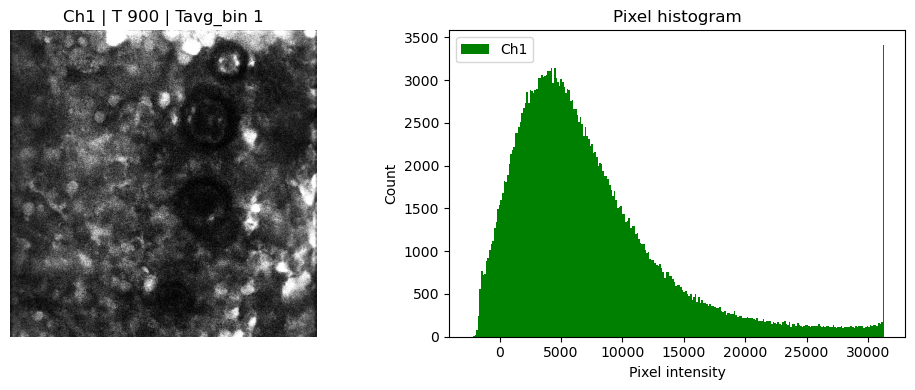

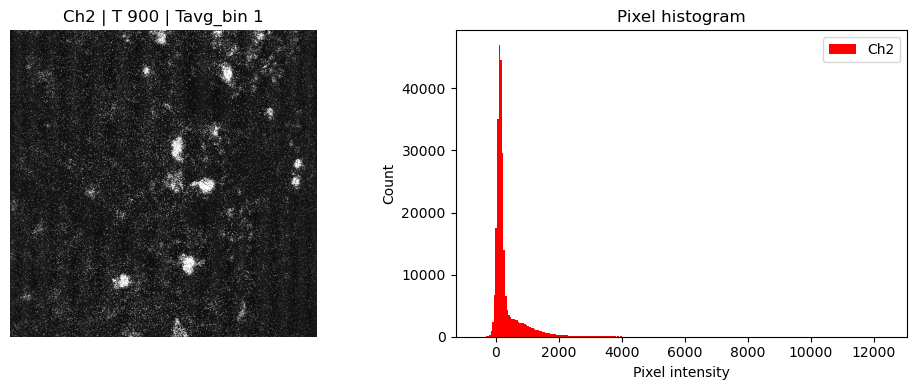

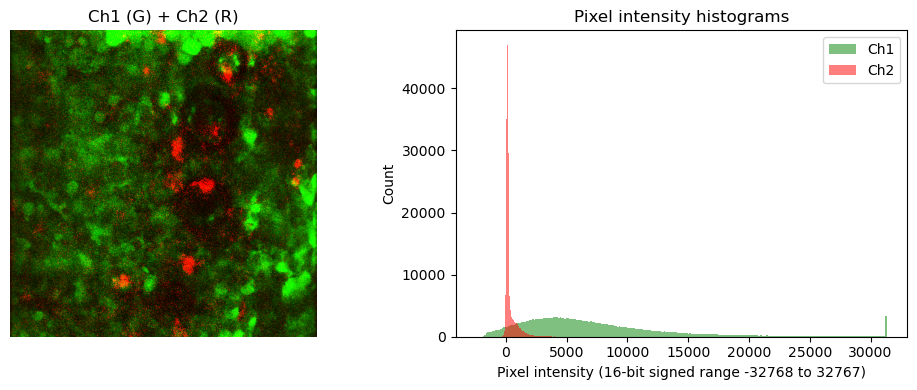

In [309]:
# Sanity check the channels - w/ histograms and ch1+ch2 overlay

# import numpy as np
# import matplotlib.pyplot as plt

def plot_slice_histogram(img, histcolor, zsliceNum=0, frame='Avg', channel='signal'):
    # img = channel_1_data[:, :, frame]
    pixels = img.ravel()
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Image
    vmin = np.percentile(img, 1)
    vmax = np.percentile(img, 99)

    axes[0].imshow(img, cmap='gray',
               vmin=vmin,
               vmax=vmax)
    #axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'{channel} | T {zsliceNum} | Tavg_bin {bin_size}')
    axes[0].axis('off')
    
    # Histogram
    # axes[1].hist(pixels, bins=256, density=True, color=histcolor)
    axes[1].hist(pixels, bins=256, density=False, color=histcolor, label=channel)
    axes[1].set_xlabel('Pixel intensity')
    # axes[1].set_ylabel('Probability density')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Pixel histogram')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

def plot_overlay_and_hist(img1, img2, zsliceNum=0, frame=None,
                          bins=256, alpha=0.5, Saturation=32767):
    """
    img1, img2: (Y, X) arrays for channel 1 and channel 2
    """

    # Build RGB overlay (normalize for display only)
    # def norm(im):
    #     im = im.astype(float)
    #     return (im - im.min()) / (im.max() - im.min() + 1e-9)
    def norm(im, pmin=1, pmax=99):
        im = im.astype(float)
        vmin = np.percentile(im, pmin)
        vmax = np.percentile(im, pmax)
        return np.clip((im - vmin) / (vmax - vmin + 1e-9), 0, 1)

    rgb = np.zeros((*img1.shape, 3))
    rgb[..., 1] = norm(img1)   # green
    rgb[..., 0] = norm(img2)   # red

    # Flatten pixels
    p1 = img1.ravel()
    p2 = img2.ravel()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # ---- Overlay image ----
    axes[0].imshow(rgb)
    title = "Ch1 (G) + Ch2 (R)"
    if zsliceNum is not None and frame is not None:
        title += f" | T {zsliceNum} | Tavg_bin {bin_size}"
    axes[0].set_title(title)
    axes[0].axis('off')

    # ---- Overlaid histograms ----
    axes[1].hist(p1, bins=bins, density=False,
                 color='green', alpha=alpha, label='Ch1')
    axes[1].hist(p2, bins=bins, density=False,
                 color='red', alpha=alpha, label='Ch2')

    axes[1].set_xlabel(f'Pixel intensity (16-bit signed range -32768 to 32767)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Pixel intensity histograms')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def preprocess_background(img, bg_pctle=5, norm_pctle=99):
    # perform background subtraction and normalization
    # 1. Keep raw int16 data untouched
    img_raw = img
    
    # 2. Background subtract (robust)
    bg = np.percentile(img_raw, bg_pctle)
    img_bg = img_raw - bg
    
    # 3. (Optional) Normalize to reference
    img_norm = img_bg / np.percentile(img_bg, norm_pctle)

    return img_bg, img_norm

# run the functions here
# frame = 5 # select T frame
# img_chan1 = channel_1_data[:, :, frame]
# img_chan2 = channel_2_data[:, :, frame]

# Need to distinguish Z, T etc explicitlu hehre
img_chan1 = channel_1_data[:, :, tsliceNum]
img_chan2 = channel_2_data[:, :, tsliceNum]

img_chan1_background, img_chan1_normalized = preprocess_background(img_chan1, bg_pctle=5, norm_pctle=99)
img_chan2_background, img_chan2_normalized = preprocess_background(img_chan2, bg_pctle=5, norm_pctle=99)

plot_slice_histogram(img_chan1_background, 'green', tsliceNum, channel='Ch1')
plot_slice_histogram(img_chan2_background, 'red', tsliceNum, channel='Ch2')
plot_overlay_and_hist(img_chan1_background, img_chan2_background,
                      zsliceNum=tsliceNum, frame=None)


In [310]:
# Z data averaged over T (e.g. (Z,C,Y,X))
# use for Z T-avg'ed data (ie Avg_Zi = Σ(T_0...T_19) / 20)

channel_1_data = tif_binned[:, 0, :, :]  # shape: (33, 512, 512)
channel_2_data = tif_binned[:, 1, :, :]  # shape: (33, 512, 512)

print(f"Channel 1   shape: {channel_1_data.shape}")
print(f"Channel 2   shape: {channel_2_data.shape}")

# Transpose to (Y, X, Z) if needed for your code
channel_1_data = np.transpose(channel_1_data, (1, 2, 0))  # shape: (512, 512, 33)
channel_2_data = np.transpose(channel_2_data, (1, 2, 0))  # shape: (512, 512, 33)

print(f"Channel 1 reshape: {channel_1_data.shape}")
print(f"Channel 2 reshape: {channel_2_data.shape}")

Channel 1   shape: (1800, 512, 512)
Channel 2   shape: (1800, 512, 512)
Channel 1 reshape: (512, 512, 1800)
Channel 2 reshape: (512, 512, 1800)


In [311]:
print(tif_data.dtype)
print("min:", tif_data.min())
print("max:", tif_data.max())

print(tif_binned.dtype)
print("min:", tif_binned.min())
print("max:", tif_binned.max())

int16
min: -4818
max: 32767
float64
min: -4818.0
max: 32767.0


In [312]:
"""
Notes / knobs you’ll likely tweak

If your Ch2 medians routinely exceed 12k (bright dyes / high gain), bump:

ylim_med_ch2 = (0, 20000) (or 30000)

If your IQR is usually >2000 (dense structure), bump:

ylim_iqr_ch2 = (0, 4000)

If you want the guideline lines to be bands instead of individual lines (shaded zones), I can swap to axhspan().
"""
# QC thresholds (recap, encoded once)
# ---- QC thresholds (int16 ScanImage-style) ----
SAT = 32767

# Median (intensity)
MED_DIM = 500
MED_GOOD_LO, MED_GOOD_HI = 1000, 8000
MED_HOT_HI = 15000

# IQR (contrast / structure)
IQR_LOW = 50
IQR_GOOD_LO, IQR_GOOD_HI = 100, 800
IQR_CEIL = 2000

# Saturation fraction
SAT_WARN = 0.01     # 1%
SAT_BAD  = 0.05     # 5%


In [313]:
"""
How to interpret these (especially for tdTomato)

For a sparse red channel:
"""

"""
Sparse-channel interpretation (important for tdTomato)
Because tdTomato is often sparse:
    p50 (median) mostly reflects background
    p99 and top_mean track structural signal
    > bright_frac is a sensitive detector of area change

If:
p50 stable
p99 fluctuates
→ biological modulation of bright structures.

If:
p50 drifts
p99 stable
→ baseline instability.

What to look for in a T-averaged (60-frame) stack
If you averaged 60 frames:
    Fast noise should be suppressed
    Slow drifts become clearer
    Bleaching trends become easier to quantify
    Transient spikes are smoothed
So trends across T are more likely to represent:
    power drift
    bleaching
    motion band
    biological modulation
    rather than shot noise.
-------------
Per-T, per-channel summary metrics:

Baseline-sensitive
p5 (or p10) → background / offset
p50 → bulk intensity

Signal-sensitive
p95
p99
top_mean (top 0.5% brightest pixels)

Contrast
dr = p99 − p5

Clipping
sat (≥ SAT)
near_sat (≥ SAT − margin)

(For time series: sudden spikes in sat can indicate motion or transient overexposure.)

"""

# import numpy as np
# import matplotlib.pyplot as plt

SAT = 32767

def qc_per_z_extended(channel_idx, *,
                      p_lo=5, p_hi1=95, p_hi2=99,
                      top_frac=0.005,          # top 0.5%
                      near_sat_margin=500,      # counts below SAT
                      bright_thresh_mode="p99"  # "p99" or "p995" or numeric
                     ):
    """
    tif_data expected shape: (Z, T, C, Y, X)
    Returns dict of per-Z metrics.
    """
    Z = tif_data.shape[0]   # ← derive from data, not global
    
    med = np.zeros(Z)
    iqr = np.zeros(Z)
    sat = np.zeros(Z)

    p5 = np.zeros(Z)
    p50 = np.zeros(Z)
    p95 = np.zeros(Z)
    p99 = np.zeros(Z)
    dr = np.zeros(Z)

    near_sat = np.zeros(Z)

    top_mean = np.zeros(Z)
    bright_frac = np.zeros(Z)

    for z in range(Z):
        img = tif_data[z, channel_idx, :, :].mean(axis=0)  # (Y,X)
        px = img.ravel()

        # percentiles
        p5[z]  = np.percentile(px, p_lo)
        p50[z] = np.percentile(px, 50)
        p95[z] = np.percentile(px, p_hi1)
        p99[z] = np.percentile(px, p_hi2)
        dr[z]  = p99[z] - p5[z]

        # legacy metrics (keep)
        med[z] = p50[z]
        iqr[z] = np.percentile(px, 75) - np.percentile(px, 25)
        sat[z] = np.mean(px >= SAT)
        near_sat[z] = np.mean(px >= (SAT - near_sat_margin))

        # top fraction mean (sparse-signal proxy)
        k = max(1, int(np.floor(top_frac * px.size)))
        # partition is faster than full sort
        topk = np.partition(px, -k)[-k:]
        top_mean[z] = np.mean(topk)

        # bright fraction above threshold
        if isinstance(bright_thresh_mode, (int, float)):
            thr = bright_thresh_mode
        else:
            if bright_thresh_mode == "p99":
                thr = p99[z]
            elif bright_thresh_mode == "p995":
                thr = np.percentile(px, 99.5)
            elif bright_thresh_mode == "p999":
                thr = np.percentile(px, 99.9)
            else:
                thr = p99[z]
        bright_frac[z] = np.mean(px > thr)

    return {
        "p5": p5, "p50": p50, "p95": p95, "p99": p99,
        "dr": dr,
        "iqr": iqr,
        "sat": sat, "near_sat": near_sat,
        "top_mean": top_mean,
        "bright_frac": bright_frac,
    }

qc1 = qc_per_z_extended(0)  # Ch1
qc2 = qc_per_z_extended(1)  # Ch2

print(f'Saturation set at {SAT} & quality control function(s) loaded. Run the next cell...')
print(list(qc1.keys()))

Saturation set at 32767 & quality control function(s) loaded. Run the next cell...
['p5', 'p50', 'p95', 'p99', 'dr', 'iqr', 'sat', 'near_sat', 'top_mean', 'bright_frac']


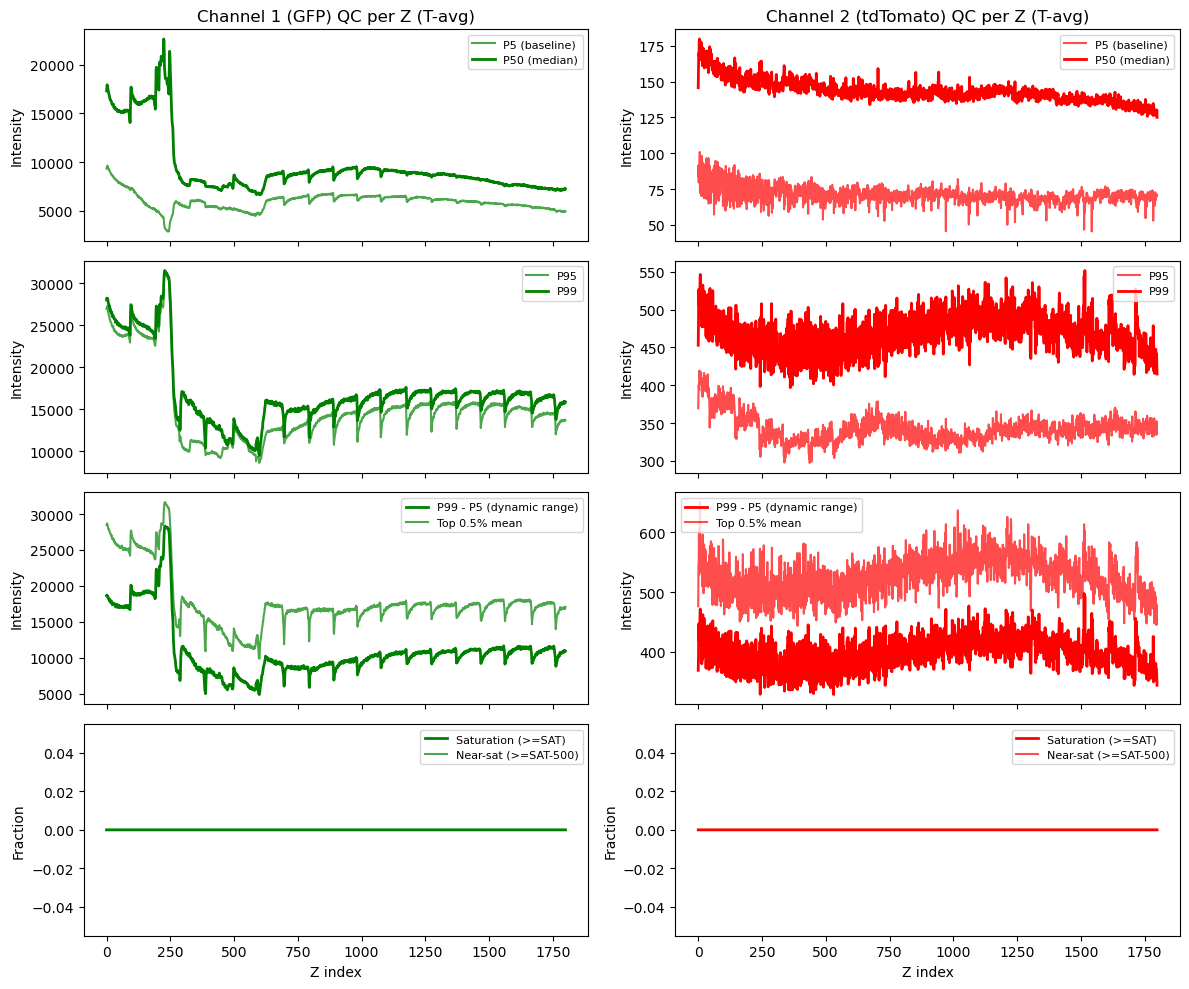

In [314]:
# Plotting: a “high-value” QC figure (4 rows × 2 cols)
# This replaces your 3×2 with something more informative for sparse channels.
fig, ax = plt.subplots(4, 2, figsize=(12, 10), sharex=True)

def plot_channel(col, qc, color, title):
    # Row 1: Baseline + central tendency
    ax[0, col].plot(qc["p5"],  color=color, alpha=0.7, label="P5 (baseline)")
    ax[0, col].plot(qc["p50"], color=color, lw=2, label="P50 (median)")
    ax[0, col].set_title(title)
    ax[0, col].set_ylabel("Intensity")
    ax[0, col].legend(fontsize=8)

    # Row 2: Signal-sensitive percentiles
    ax[1, col].plot(qc["p95"], color=color, alpha=0.7, label="P95")
    ax[1, col].plot(qc["p99"], color=color, lw=2, label="P99")
    ax[1, col].set_ylabel("Intensity")
    ax[1, col].legend(fontsize=8)

    # Row 3: Contrast + sparse-signal proxy
    ax[2, col].plot(qc["dr"],       color=color, lw=2, label="P99 - P5 (dynamic range)")
    ax[2, col].plot(qc["top_mean"], color=color, alpha=0.7, label="Top 0.5% mean")
    ax[2, col].set_ylabel("Intensity")
    ax[2, col].legend(fontsize=8)

    # Row 4: Clipping / saturation
    ax[3, col].plot(qc["sat"],      color=color, lw=2, label="Saturation (>=SAT)")
    ax[3, col].plot(qc["near_sat"], color=color, alpha=0.7, label="Near-sat (>=SAT-500)")
    ax[3, col].set_ylabel("Fraction")
    ax[3, col].set_xlabel("Z index")
    ax[3, col].legend(fontsize=8)

plot_channel(0, qc1, "green", "Channel 1 (GFP) QC per Z (T-avg)")
plot_channel(1, qc2, "red",   "Channel 2 (tdTomato) QC per Z (T-avg)")

plt.tight_layout()
plt.show()

# Match y-lims across channels for each row (like you already do)
for row in range(ax.shape[0]):
    ymins = [ax[row, 0].get_ylim()[0], ax[row, 1].get_ylim()[0]]
    ymaxs = [ax[row, 0].get_ylim()[1], ax[row, 1].get_ylim()[1]]
    ymin, ymax = min(ymins), max(ymaxs)
    ax[row, 0].set_ylim(ymin, ymax)
    ax[row, 1].set_ylim(ymin, ymax)


In [315]:
# Get CSV metadata for ScanImage TXYZ TIF files
# Output image metadata to csv- and/or txt-friendly format

from pathlib import Path
import json
import socket
import platform
import re
import pandas as pd
import tifffile as tiff
from datetime import datetime

def _parse_epoch_line(desc_text: str):
    """
    Parse ScanImage epoch line like:
      epoch = [2026  1 13 16 24 29.809]
    Returns datetime or None.
    """
    if not desc_text:
        return None, None

    m = re.search(r"(?m)^epoch\s*=\s*\[([^\]]+)\]\s*$", desc_text)
    if not m:
        return None, None

    raw = m.group(1).strip()  # "2026  1 13 16 24 29.809"
    parts = [p for p in re.split(r"\s+", raw) if p]
    if len(parts) < 6:
        return None, raw

    y = int(float(parts[0]))
    mo = int(float(parts[1]))
    d = int(float(parts[2]))
    h = int(float(parts[3]))
    mi = int(float(parts[4]))
    sec = float(parts[5])

    sec_int = int(sec)
    usec = int(round((sec - sec_int) * 1e6))
    dt = datetime(y, mo, d, h, mi, sec_int, usec)
    return dt, raw

def _get_si_value(software_text: str, key: str):
    """
    Extract a ScanImage 'SI.key = value' line from the Software tag text.
    Returns the value string (stripped) or None.
    """
    if not software_text:
        return None
    m = re.search(rf"(?m)^{re.escape(key)}\s*=\s*(.*)$", software_text)
    return m.group(1).strip() if m else None

def _parse_si_vector(txt):
    if not txt:
        return None
    s = txt.strip().strip("[]")
    parts = [p for p in s.replace(",", " ").split() if p]
    try:
        return [float(p) for p in parts]
    except ValueError:
        return None

def fov_um_from_tiff_resolution(page):
    tags = page.tags

    # XResolution/YResolution are (num, denom) tuples
    res_x_num, res_x_den = tags["XResolution"].value
    res_y_num, res_y_den = tags["YResolution"].value
    res_x = res_x_num / res_x_den  # pixels per unit
    res_y = res_y_num / res_y_den

    unit = tags["ResolutionUnit"].value  # 2=inches, 3=cm

    height, width = page.shape  # rows, cols

    if unit == 3:  # cm
        width_um  = (width  / res_x) * 1e4
        height_um = (height / res_y) * 1e4
    elif unit == 2:  # inch
        width_um  = (width  / res_x) * 25400
        height_um = (height / res_y) * 25400
    else:
        return None, None, None, None  # unsupported / missing

    um_per_px_x = width_um / width
    um_per_px_y = height_um / height
    
    return width_um, height_um, um_per_px_x, um_per_px_y


def export_scanimage_metadata(tif_path, out_csv=None):
    tif_path = Path(tif_path)

    with tiff.TiffFile(tif_path) as tf:
        p0 = tf.pages[0]
        
        # FOV fallback from TIFF resolution tags (matches what Fiji reports)
        fov_x_um_tiff, fov_y_um_tiff, um_per_pixel_x_tiff, um_per_pixel_y_tiff = fov_um_from_tiff_resolution(p0)


        software = str(p0.tags.get("Software").value) if p0.tags.get("Software") else ""
        artist = str(p0.tags.get("Artist").value) if p0.tags.get("Artist") else ""
        desc = str(p0.tags.get("ImageDescription").value) if p0.tags.get("ImageDescription") else ""

        imaging_fov_um = _get_si_value(software, "SI.hRoiManager.imagingFovUm")

        # ---------- File info ----------
        stat = tif_path.stat()
        file_created = datetime.fromtimestamp(stat.st_ctime)
        file_modified = datetime.fromtimestamp(stat.st_mtime)

        # ---------- Acquisition epoch -> datetime ----------
        acq_dt, acq_epoch_raw = _parse_epoch_line(desc)

        # # ---------- ROI geometry (Artist tag JSON) ----------
        # fov_x_um = fov_y_um = px_x = px_y = None
        # scan_zoom_factor = None
        # try:
        #     roi_root = json.loads(artist)
        #     roi = roi_root["RoiGroups"]["imagingRoiGroup"]["rois"]
        #     scanfield = roi["scanfields"]
        #     # fov_x_um, fov_y_um = scanfield["sizeXY"]
        #     fov_xy = _parse_si_vector(imaging_fov_um)

        #     if fov_xy and len(fov_xy) == 2:
        #         fov_x_um, fov_y_um = fov_xy
        #         um_per_pixel_x = fov_x_um / px_x
        #         um_per_pixel_y = fov_y_um / px_y
        #     else:
        #         fov_x_um = fov_y_um = um_per_pixel_x = um_per_pixel_y = None

        #     px_x, px_y = scanfield["pixelResolutionXY"]
        #     scan_zoom_factor = roi.get("UserData", {}).get("scanZoomFactor", None)

        # except Exception:
        #     # If Artist isn't valid JSON, just leave these as None
        #     pass
        # ---------- ROI geometry (Artist tag JSON) ----------
        fov_x_um = fov_y_um = px_x = px_y = None
        um_per_pixel_x = um_per_pixel_y = None
        scan_zoom_factor = None
        
        try:
            roi_root = json.loads(artist)
            roi = roi_root["RoiGroups"]["imagingRoiGroup"]["rois"]
            scanfield = roi["scanfields"]
        
            # pixel dims (needed for um/px)
            px_x, px_y = scanfield["pixelResolutionXY"]
        
            # calibrated FOV from Software tag (preferred)
            fov_xy = _parse_si_vector(imaging_fov_um)
            if fov_xy and len(fov_xy) == 2 and px_x and px_y:
                fov_x_um, fov_y_um = fov_xy
                um_per_pixel_x = fov_x_um / px_x
                um_per_pixel_y = fov_y_um / px_y
        
            scan_zoom_factor = roi.get("UserData", {}).get("scanZoomFactor", None)
        
        except Exception:
            pass
            
        # Fallback if ScanImage FOV is missing
        if fov_x_um is None and fov_x_um_tiff is not None:
            fov_x_um = fov_x_um_tiff
            fov_y_um = fov_y_um_tiff
            um_per_pixel_x = um_per_pixel_x_tiff
            um_per_pixel_y = um_per_pixel_y_tiff
            fov_source = "tiff_resolution_tags"
        else:
            fov_source = "scanimage_imagingFovUm" if fov_x_um is not None else "missing"

        # ---------- Basic image geometry from TIFF page ----------
        # tifffile pages have shape, but tags are reliable:
        image_width_px = getattr(p0, "imagewidth", None)
        image_height_px = getattr(p0, "imagelength", None)

        # imaging_fov_um = _get_si_value(software, "SI.hRoiManager.imagingFovUm")

        # ---------- ScanImage version / files ----------
        ver_major = _get_si_value(software, "SI.VERSION_MAJOR")
        ver_minor = _get_si_value(software, "SI.VERSION_MINOR")
        ver_update = _get_si_value(software, "SI.VERSION_UPDATE")

        scanimage_version = None
        if ver_major and ver_minor and ver_update:
            scanimage_version = f"{ver_major}.{ver_minor}.{ver_update}"

        # ---------- Channels / optics ----------
        channels_saved = _get_si_value(software, "SI.hChannels.channelSave")
        channel_names = _get_si_value(software, "SI.hChannels.channelName")
        frame_rate_hz = _get_si_value(software, "SI.hRoiManager.scanFrameRate")

        # NOTE: In your screenshot + file dump, laser wavelength is from the laser UI,
        # but ScanImage often stores it as part of beam "powers" or separate fields depending on integration.
        # We'll still report beam powers & power fractions when present.
        beam_power_mw = _get_si_value(software, "SI.hBeams.powers")
        beam_power_fraction = _get_si_value(software, "SI.hBeams.powerFractions")

        # PMT gains are controller-specific; may be missing in some configs
        pmt_gains = _get_si_value(software, "SI.hPmts.gain")
        pmt_offsets = _get_si_value(software, "SI.hChannels.channelOffset")

        # ---------- Scanner type ---------- #begin_new1
        scanner_name = (_get_si_value(software, "SI.hScan2D.scannerType")
                        or _get_si_value(software, "SI.hScan2D.name"))
        scanner_resonant = _get_si_value(software, "SI.hScan2D.resonantScannerEnable")
        # scanner_bidirectional = _get_si_value(software, "SI.hScan2D.bidirectionalScan")
        line_rate_hz = _get_si_value(software, "SI.hScan2D.scanLineRate")

        # Scanner classification
        scanner_resonant_enabled = (scanner_name == "'RGG'")
        
        # Resonant scanners are inherently bidirectional
        scanner_bidirectional = True if scanner_resonant_enabled else _get_si_value(
            software, "SI.hScan2D.bidirectionalScan"
        )
        
        # Line rate is not logged for resonant scanners
        scan_line_rate_hz = None
        scan_line_rate_note = (
            "Resonant scanner line rate is hardware-defined and not written to TIFF metadata"
            if scanner_resonant_enabled else "Derived from ScanImage metadata"
        )
        # Can manually derive from fps value and pixels
        512/30
        Out[2]: 17.066666666666666
        
        17.067*30
        Out[5]: 512.01
        
        17.0667*512
        Out[6]: 8738.1504
        
        # ---------- Pockels / power ----------
        pockels_power_fractions = _get_si_value(software, "SI.hBeams.powerFractions")
        pockels_power_limits = _get_si_value(software, "SI.hBeams.powerFractionLimits")
        pockels_lut_source = _get_si_value(software, "SI.hBeams.pzLUTSource")
        pockels_pz_adjust = _get_si_value(software, "SI.hBeams.pzAdjust")
        pockels_flyback_blanking = _get_si_value(software, "SI.hBeams.flybackBlanking")
        pockels_turnaround_blanking = _get_si_value(software, "SI.hBeams.turnAroundBlanking")
        
        # If your config logs absolute mW in SI.hBeams.powers, keep that too:
        beam_powers_mw = _get_si_value(software, "SI.hBeams.powers")
        
        # ---------- PMT values ----------
        # Gains are sometimes here; offsets often under hChannels
        pmt_gains = (_get_si_value(software, "SI.hPmts.gain")
                     or _get_si_value(software, "SI.hPmts.gains"))
        pmt_offsets = (_get_si_value(software, "SI.hChannels.channelOffset")
                       or _get_si_value(software, "SI.hPmts.offset"))
        
        # ---------- Frames averaged / averaging ----------
        # Display rolling average is NOT acquisition averaging; you want these when present:
        log_avg_enable = _get_si_value(software, "SI.hScan2D.logAverageEnable")
        log_avg_factor = _get_si_value(software, "SI.hScan2D.logAverageFactor")
        
        # Also useful: scan/recording averaging modes can vary across versions:
        # (These might not exist in every config; safe to keep.)
        scan_avg_enable = _get_si_value(software, "SI.hScan2D.scanAverageEnable")
        scan_avg_factor = _get_si_value(software, "SI.hScan2D.scanAverageFactor") #end new1

        # Objective name exists only if the objective manager is configured
        objective_name = _get_si_value(software, "SI.hObjectiveManager.objectiveName")

        # ---------- TIFF structure ----------
        num_frames = len(tf.pages)
        timestamps_present = "frameTimestamps_sec" in desc

        # ---------- Derived um/px ----------
        um_per_pixel_x = (float(fov_x_um) / float(px_x)) if (fov_x_um and px_x) else None
        um_per_pixel_y = (float(fov_y_um) / float(px_y)) if (fov_y_um and px_y) else None

        row = {
            # File / identity
            "filename": tif_path.name,
            "full_path": str(tif_path),
            "file_size_mb": round(stat.st_size / 1e6, 2),
            "file_created_time": file_created.isoformat(),
            "file_modified_time": file_modified.isoformat(),
            "acquisition_datetime": acq_dt.isoformat() if acq_dt else None,
            "acquisition_epoch_raw": acq_epoch_raw,
            "scanimage_version": scanimage_version,
            "scanimage_commit": _get_si_value(software, "SI.VERSION_COMMIT"),
            "scanimage_premium": _get_si_value(software, "SI.PREMIUM"),
            "config_file": _get_si_value(software, "SI.hConfigurationSaver.cfgFilename"),
            "user_file": _get_si_value(software, "SI.hConfigurationSaver.usrFilename"),
            "host_os": platform.platform(),
            "host_machine": socket.gethostname(),
            "fov_source": fov_source,

            # Image geometry
            "pixels_per_line": px_x,
            "lines_per_frame": px_y,
            "image_width_px": image_width_px,
            "image_height_px": image_height_px,
            "fov_x_um": fov_x_um,
            "fov_y_um": fov_y_um,
            "um_per_pixel_x": um_per_pixel_x,
            "um_per_pixel_y": um_per_pixel_y,

            # Acquisition structure
            "num_frames": num_frames,
            "frame_rate_hz": frame_rate_hz,
            "timestamps_present": timestamps_present,
            "channels_saved": channels_saved,
            "channel_names": channel_names,
            "bit_depth": p0.bitspersample if hasattr(p0, "bitspersample") else None,
            "samples_per_pixel": getattr(p0, "samplesperpixel", None),
            "planar_configuration": getattr(p0, "planarconfiguration", None),

            # Scanner
            # "scanner_name": scanner_name,
            # "scanner_resonant_enabled": scanner_resonant,
            # "scanner_bidirectional": scanner_bidirectional,
            # "scan_line_rate_hz": line_rate_hz,
            "scanner_name": scanner_name,
            "scanner_resonant_enabled": scanner_resonant_enabled,
            "scanner_bidirectional": scanner_bidirectional,
            "scan_line_rate_hz": scan_line_rate_hz,
            "scan_line_rate_note": scan_line_rate_note,
            
            # Pockels / power
            "pockels_power_fractions": pockels_power_fractions,
            "pockels_power_limits": pockels_power_limits,
            "pockels_lut_source": pockels_lut_source,
            "pockels_pz_adjust": pockels_pz_adjust,
            "pockels_flyback_blanking": pockels_flyback_blanking,
            "pockels_turnaround_blanking": pockels_turnaround_blanking,
            "beam_powers_mw": beam_powers_mw,
            
            # PMTs
            "pmt_gains": pmt_gains,
            "pmt_offsets": pmt_offsets,
            
            # Averaging (acquisition/log averaging when present)
            "log_avg_enable": log_avg_enable,
            "log_avg_factor": log_avg_factor,
            "scan_avg_enable": scan_avg_enable,
            "scan_avg_factor": scan_avg_factor,

            # Optics / laser
            "objective_name": objective_name,
            "scan_zoom_factor": scan_zoom_factor,
            "beam_power_mw": beam_power_mw,
            "beam_power_fraction": beam_power_fraction,
            "pmt_offsets": pmt_offsets,
            "pmt_gains": pmt_gains,

            # Z semantics (explicit & honest)
            "acquisition_type": "single_plane",
            "z_logged": "no",
            "z_reference": "roi_relative_zero",
            "z_note": "Single-plane T-series; no StackManager/FastZ Z positions logged into TIFF",
        }

    print("TIFF resolution tags FOV:", fov_x_um_tiff, "*", fov_y_um_tiff, "um;", "um/px:", "x=", um_per_pixel_x_tiff, "y=", um_per_pixel_y_tiff)
    
    print('   ')
    print('*** A new CSV file should appear in the source-file (ie TIF) directory ***')    
    
    df = pd.DataFrame([row])

    df_kv = df.T.reset_index()
    df_kv.columns = ["field", "value"]


    if out_csv is None:
        out_csv = tif_path.with_suffix("").as_posix() + "_metadata.csv"
    df_kv.to_csv(out_csv, index=False)
    return df_kv

print("Function loaded, ready to run def(export_scanimage_metadata)...")

Function loaded, ready to run def(export_scanimage_metadata)...


In [316]:
print(tif_filename1)

export_scanimage_metadata(
    tif_file1
)

# Notes  remember that 'num_frames' will represent 2 channels
# so the actual frames_per_chan = num_frames/channels_saved
# (eg if 1800 frames were acquired per channel, num_frames=3600 and channels_saved=2; frames_per_chan = num_frames/2)

T1800_25x3x_930nm_area07_00001.tif
TIFF resolution tags FOV: 162.99724578857422 * 162.99724578857422 um; um/px: x= 0.318353995680809 y= 0.318353995680809
   
*** A new CSV file should appear in the source-file (ie TIF) directory ***


,field,value
0,filename,T1800_25x3x_930nm_area07_00001.tif
1,full_path,/Users/jcoleman/Documents/--LARGE DATA--/#VonR...
2,file_size_mb,1896.04
3,file_created_time,2026-01-15T18:47:39.432048
4,file_modified_time,2026-01-15T16:10:40
5,acquisition_datetime,2026-01-15T16:09:39.981000
6,acquisition_epoch_raw,2026 1 15 16 9 39.981
7,scanimage_version,2023.1.1
8,scanimage_commit,'6fa08573b737b7ca5870c37cdb5781839365bdf6'
9,scanimage_premium,true


In [317]:
print(tif_filename2)

export_scanimage_metadata(
    tif_file2
)

T1800_25x3x_1100nm_area07_00001.tif
TIFF resolution tags FOV: 162.99724578857422 * 162.99724578857422 um; um/px: x= 0.318353995680809 y= 0.318353995680809
   
*** A new CSV file should appear in the source-file (ie TIF) directory ***


,field,value
0,filename,T1800_25x3x_1100nm_area07_00001.tif
1,full_path,/Users/jcoleman/Documents/--LARGE DATA--/#VonR...
2,file_size_mb,1896.04
3,file_created_time,2026-01-15T18:48:04.901153
4,file_modified_time,2026-01-15T16:12:58
5,acquisition_datetime,2026-01-15T16:11:56.130000
6,acquisition_epoch_raw,2026 1 15 16 11 56.130
7,scanimage_version,2023.1.1
8,scanimage_commit,'6fa08573b737b7ca5870c37cdb5781839365bdf6'
9,scanimage_premium,true


In [318]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import signal

# def detrend_moving_average(x, win):
#     x = np.asarray(x, float)
#     ma = signal.convolve(x, np.ones(win)/win, mode="same")
#     return x - ma

# def welch_psd(x, fs, nperseg=None):
#     x = np.asarray(x, float)
#     x = signal.detrend(x)  # removes linear trend
#     f, Pxx = signal.welch(x, fs=fs, nperseg=nperseg or min(256, len(x)))
#     return f, Pxx

# def top_peaks(f, Pxx, n=5, fmin=0.01, fmax=20):
#     mask = (f >= fmin) & (f <= fmax)
#     ff, pp = f[mask], Pxx[mask]
#     pk, props = signal.find_peaks(pp, prominence=np.max(pp)*0.02)
#     order = np.argsort(pp[pk])[::-1][:n]
#     return list(zip(ff[pk][order], pp[pk][order]))

# # Example usage:
# # x = top_mean_red  # 1D array over T bins
# # fs = 0.5          # Hz (example)
# # x_d = detrend_moving_average(x, win=15)
# # f, P = welch_psd(x_d, fs)
# # print("Top peaks (Hz, power):", top_peaks(f, P))

# def plot_spectrogram_with_trace(x, fs,
#                                  nperseg=256,
#                                  noverlap=200,
#                                  fmax=15,
#                                  cmap="magma"):

#     x = np.asarray(x, float)
#     x = signal.detrend(x)

#     # Compute STFT
#     f, t, Sxx = signal.spectrogram(
#         x,
#         fs=fs,
#         nperseg=nperseg,
#         noverlap=noverlap,
#         scaling='density',
#         mode='psd'
#     )

#     # Limit frequency range
#     mask = f <= fmax
#     f = f[mask]
#     Sxx = Sxx[mask, :]

#     # Convert to dB for better visibility
#     Sxx_db = 10 * np.log10(Sxx + 1e-12)

#     # ---- Plot ----
#     fig = plt.figure(figsize=(10, 7))

#     # Top: signal trace
#     ax1 = plt.subplot(2,1,1)
#     time = np.arange(len(x)) / fs
#     ax1.plot(time, x, color="black", linewidth=1)
#     ax1.set_ylabel("Signal")
#     ax1.set_title("Signal Trace")

#     # Bottom: spectrogram
#     ax2 = plt.subplot(2,1,2, sharex=ax1)
#     im = ax2.pcolormesh(t, f, Sxx_db,
#                         shading='gouraud',
#                         cmap=cmap)
#     ax2.set_ylabel("Frequency (Hz)")
#     ax2.set_xlabel("Time (s)")
#     ax2.set_title("Power Spectrogram")

#     plt.colorbar(im, ax=ax2, label="Power (dB)")

#     plt.tight_layout()
#     plt.show()

#     return f, t, Sxx_db

# # NOTE: Only run this section when your 'bin_size=1 (ie raw T w/ no averaging for higher fs @ 30fps)
# x=qc1['top_mean']
# fs = 30         # Hz (example)
# x_d = detrend_moving_average(x, win=15)
# f, P = welch_psd(x_d, fs)
# print("Top peaks (Hz, power):", top_peaks(f, P))
# # plt.plot(x)

# plot_spectrogram_with_trace(x, fs,
#                                  nperseg=256,
#                                  noverlap=200,
#                                  fmax=15,
#                                  cmap="magma")

In [319]:
# # NOTE: Only run this section when your 'bin_size=1 (ie raw T w/ no averaging for higher fs @ 30fps)
# """
# ESCAPE+M ==> convert cell to Markdown; ESCAPE+Y==> convert back to code
# Run this to inspect large drifts and spikes in signals - still experimental
# Rough guide for monitoring breathing rate from image spikes
# - As a general monitoring window. 1–2 Hz (60–120 bpm) is the standard range for anesthesia.

# """

# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import signal

# def plot_clean_breathing_qc(
#     x, fs,
#     bad_idx=None,
#     nperseg=256,
#     noverlap=200,
#     fmax=15,
#     breath_band_hz=(0.6, 3.5),
#     bpm_summary="median"
# ):

#     x = np.asarray(x, float)
#     time = np.arange(len(x)) / fs
#     x_d = signal.detrend(x)

#     # Spectrogram
#     f, t, Sxx = signal.spectrogram(
#         x_d, fs=fs,
#         nperseg=nperseg,
#         noverlap=noverlap,
#         scaling='density',
#         mode='psd'
#     )

#     mask = f <= fmax
#     f = f[mask]
#     Sxx = Sxx[mask]
#     Sxx_db = 10*np.log10(Sxx + 1e-12)

#     # Breathing band dominant frequency
#     f_lo, f_hi = breath_band_hz
#     mb = (f >= f_lo) & (f <= f_hi)
#     band_f = f[mb]
#     band_S = Sxx[mb, :]
#     idx = np.argmax(band_S, axis=0)
#     breath_freq_t = band_f[idx]
#     breath_bpm_t = 60 * breath_freq_t
#     bpm_est = float(np.median(breath_bpm_t))

#     # ---- Layout ----
#     fig = plt.figure(figsize=(12, 9))
#     gs = fig.add_gridspec(3, 1, height_ratios=[1, 2.2, 0.9], hspace=0.3)

#     ax1 = fig.add_subplot(gs[0, 0])
#     ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
#     ax3 = fig.add_subplot(gs[2, 0])
#     ax3.axis("off")

#     # =========================
#     # TOP: SIGNAL TRACE
#     # =========================
#     ax1.plot(time, x, color="black", linewidth=1.2)
#     ax1.set_ylabel("Signal")
#     ax1.set_title("Signal Trace")

#     # Red shaded spike zones
#     if bad_idx is not None and len(bad_idx) > 0:
#         spike_times = bad_idx / fs
#         pad = 0.15  # seconds of shading on each side
#         for st in spike_times:
#             ax1.axvspan(st - pad, st + pad,
#                         color='red', alpha=0.15)

#     # =========================
#     # MIDDLE: SPECTROGRAM
#     # =========================
#     im = ax2.pcolormesh(
#         t, f, Sxx_db,
#         shading='gouraud',
#         cmap='magma'
#     )

#     # Cyan breathing-dominant line
#     ax2.plot(
#         t, breath_freq_t,
#         linestyle='--',
#         linewidth=2,
#         color='cyan'
#     )

#     # Light shaded breathing band
#     ax2.axhspan(f_lo, f_hi, color='white', alpha=0.05)

#     ax2.set_ylim(0, fmax)
#     ax2.set_ylabel("Frequency (Hz)")
#     ax2.set_xlabel("Time (s)")
#     ax2.set_title("Power Spectrogram")

#     cbar = fig.colorbar(im, ax=ax2)
#     cbar.set_label("Power (dB)")

#     # =========================
#     # BOTTOM: CONTEXT PANEL
#     # =========================

#     clinical_text = (
#         f"Estimated Breathing Rate: {bpm_est:.0f} breaths/min "
#         f"(derived from dominant frequency in {f_lo:.1f}–{f_hi:.1f} Hz band)\n\n"
#         "Clinical Context under Isoflurane:\n"
#         "  0.83 Hz  (~50 bpm)  → Too Deep (danger zone)\n"
#         "  1.0 Hz   (60 bpm)   → Optimal anesthesia\n"
#         "  1.5 Hz   (90 bpm)   → Standard anesthesia\n"
#         "  2.0 Hz   (120 bpm)  → Light anesthesia/arousal\n"
#         "  2.5–3 Hz (150–180)  → Normal sleep/rest"
#     )

#     ax3.text(
#         0.02, 0.85,
#         clinical_text,
#         fontsize=11,
#         va='top'
#     )

#     plt.show()

#     return bpm_est

# # qc1 = ch1; qc2 = ch2
# # If you want it to auto-find spikes (per session)
# # x=qc1['top_mean']
# # fs = 30         # Hz (example)
# plot_clean_breathing_qc(
#     x=qc1['top_mean'], fs=30,
#     bad_idx=None,
#     nperseg=256,
#     noverlap=200,
#     fmax=15,
#     breath_band_hz=(0.6, 3.5),
#     bpm_summary="median"
# )

# print(f'Estimated BPM: {out["bpm_est"]}')

In [320]:
# import numpy as np
# from scipy import signal

def mad(x):
    x = np.asarray(x, float)
    m = np.nanmedian(x)
    return np.nanmedian(np.abs(x - m))

def detect_toothy_motion_spikes(
    x, fs,
    smooth_win_s=1.0,     # trend window (sec)
    poly=3,
    zthr=6.0,             # higher = fewer detections
    min_dist_s=0.6,       # minimum separation between spikes (sec)
    pad_s=0.15,           # expand mask around each spike (sec)
    merge_gap_s=0.25,     # merge close intervals (sec)
):
    """
    Detect sharp 'toothy' motion spikes (usually dips) in a 1D trace.
    Returns: bad_idx, Tmask, intervals, diag
    """
    x = np.asarray(x, float)
    T = len(x)

    # 1) Smooth trend
    win = int(round(smooth_win_s * fs))
    win = max(win, poly + 2)
    if win % 2 == 0:
        win += 1
    x_smooth = signal.savgol_filter(x, window_length=win, polyorder=poly, mode="interp")

    # 2) Residual (high-frequency-ish)
    r = x - x_smooth

    # 3) Robust thresholding on negative spikes: detect peaks in -r
    a = -r
    s = 1.4826 * mad(a) + 1e-12
    a_z = (a - np.nanmedian(a)) / s

    # Peak find: enforce min distance between spikes
    min_dist = int(round(min_dist_s * fs))
    peaks, props = signal.find_peaks(a_z, height=zthr, distance=max(1, min_dist))

    # 4) Convert peaks to intervals with padding
    pad = int(round(pad_s * fs))
    intervals = []
    for p in peaks:
        i0 = max(0, p - pad)
        i1 = min(T - 1, p + pad)
        intervals.append((i0, i1))

    # 5) Merge close intervals
    if intervals:
        intervals.sort()
        merged = [intervals[0]]
        merge_gap = int(round(merge_gap_s * fs))
        for a0, a1 in intervals[1:]:
            b0, b1 = merged[-1]
            if a0 <= b1 + merge_gap:
                merged[-1] = (b0, max(b1, a1))
            else:
                merged.append((a0, a1))
        intervals = merged

    # 6) Build mask
    bad = np.zeros(T, dtype=bool)
    for a0, a1 in intervals:
        bad[a0:a1+1] = True

    bad_idx = np.where(bad)[0]
    Tmask = ~bad

    diag = {
        "x_smooth": x_smooth,
        "resid": r,
        "spike_score": a_z,
        "peaks": peaks
    }
    return bad_idx, Tmask, intervals, diag


In [321]:
# # Claude
# # --- Full-band Welch PSD to reveal dual respiratory rhythms ---
# # from scipy import signal
# # import numpy as np
# # import matplotlib.pyplot as plt

# x = qc1['top_mean']
# fs = 30

# x_d = signal.detrend(np.asarray(x, float))
# f, Pxx = signal.welch(x_d, fs=fs, nperseg=512, noverlap=400)

# fig, ax = plt.subplots(figsize=(10, 4))
# ax.semilogy(f, Pxx, color='steelblue', lw=1.5)

# # Mark the sigh band
# ax.axvspan(0.15, 0.35, color='orange', alpha=0.2, label='Sigh band (~10–20 bpm)')
# # Mark the eupneic band
# ax.axvspan(0.6, 3.5, color='green', alpha=0.15, label='Eupneic band (36–210 bpm)')

# # Annotate peaks within each band
# sigh_mask = (f >= 0.15) & (f <= 0.35)
# if sigh_mask.any():
#     sigh_peak_f = f[sigh_mask][np.argmax(Pxx[sigh_mask])]
#     ax.axvline(sigh_peak_f, color='orange', lw=1.5, ls='--',
#                label=f'Sigh peak: {sigh_peak_f:.2f} Hz ({sigh_peak_f*60:.0f} bpm)')

# eup_mask = (f >= 0.6) & (f <= 3.5)
# if eup_mask.any():
#     eup_peak_f = f[eup_mask][np.argmax(Pxx[eup_mask])]
#     ax.axvline(eup_peak_f, color='green', lw=1.5, ls='--',
#                label=f'Eupneic peak: {eup_peak_f:.2f} Hz ({eup_peak_f*60:.0f} bpm)')

# ax.set_xlim(0, 5)
# ax.set_xlabel('Frequency (Hz)')
# ax.set_ylabel('Power spectral density (log)')
# ax.set_title('Full-band Welch PSD — Ch1 top_mean\n(looking for dual respiratory rhythms)')
# ax.legend(fontsize=9)
# plt.tight_layout()
# plt.show()
# """

# This will give you a log-scale PSD from 0–5 Hz with both bands highlighted and the dominant peak
# in each automatically annotated. If your dual-rhythm hypothesis is correct,
# you should see a clear orange peak around 0.2–0.3 Hz (the sighs) **and** a green peak around 0.83 Hz (eupneic).
#     If only the green peak exists, the sigh events may be too irregular/aperiodic to show up spectrally — 
# which would also be informative.
# """




In [322]:
# # Claude re-do of 'breathing' code to catch the proper band (SIGH vs actual respiratory rate)
# def plot_clean_breathing_qc(x, fs, x2=None, bad_idx=None, intervals=None,
#                              nperseg=256, noverlap=200, fmax=15,
#                              breath_band_hz=(0.6, 3.5),
#                              sigh_band_hz=(0.15, 0.40),
#                              bpm_summary="median",
#                              burn_in_s=10.0,
#                              signal_label="qc1 / Ch1",
#                              filenames=(tif_filename1, tif_filename2)):

#     x = np.asarray(x, float)

#     # --- Burn-in exclusion ---
#     burn_in_frames = int(burn_in_s * fs)
#     x_analysis = x[burn_in_frames:]          # spectral analysis on stable window only
#     time_full   = np.arange(len(x)) / fs     # full time axis for trace plot
#     time_stable = np.arange(len(x_analysis)) / fs + burn_in_s

#     x_d = signal.detrend(x_analysis)
#     x2_d = signal.detrend(np.asarray(x2, float)[burn_in_frames:]) if x2 is not None else None

#     # --- Welch PSD ---
#     def welch_psd(sig):
#         return signal.welch(sig, fs=fs, nperseg=512, noverlap=400)

#     f_w, Pxx1 = welch_psd(x_d)
#     Pxx2 = welch_psd(x2_d)[1] if x2_d is not None else None

#     def band_peak(f, P, lo, hi):
#         mask = (f >= lo) & (f <= hi)
#         if not mask.any():
#             return None, 0.0
#         idx = np.argmax(P[mask])
#         return f[mask][idx], P[mask][idx]

#     sigh_f,  sigh_pwr  = band_peak(f_w, Pxx1, *sigh_band_hz)
#     eup_f,   eup_pwr   = band_peak(f_w, Pxx1, *breath_band_hz)

#     # Ch2 peaks for cross-ref
#     if Pxx2 is not None:
#         sigh_f2, sigh_pwr2 = band_peak(f_w, Pxx2, *sigh_band_hz)
#         eup_f2,  eup_pwr2  = band_peak(f_w, Pxx2, *breath_band_hz)
#         agree_thr = 0.05  # Hz
#         sigh_agree = (sigh_f2 is not None and abs(sigh_f - sigh_f2) <= agree_thr)
#         eup_agree  = (eup_f2  is not None and abs(eup_f  - eup_f2)  <= agree_thr)
#     else:
#         sigh_f2 = eup_f2 = None
#         sigh_agree = eup_agree = None

#     # Dominant rhythm
#     if sigh_pwr >= eup_pwr:
#         dominant     = "sigh"
#         dominant_f   = sigh_f
#         dom_label    = (f"Dominant: SIGH  {dominant_f:.2f} Hz "
#                         f"({dominant_f*60:.0f} bpm)  [sigh band wins]")
#     else:
#         dominant     = "eupneic"
#         dominant_f   = eup_f
#         dom_label    = (f"Dominant: EUPNEIC  {dominant_f:.2f} Hz "
#                         f"({dominant_f*60:.0f} bpm)  [eupneic band wins]")

#     # --- Spectrogram (stable window only) ---
#     f_s, t_s, Sxx = signal.spectrogram(x_d, fs=fs, nperseg=nperseg,
#                                         noverlap=noverlap, scaling='density', mode='psd')
#     t_s += burn_in_s   # shift time axis to match full trace
#     mask_fmax = f_s <= fmax
#     f_s    = f_s[mask_fmax]
#     Sxx    = Sxx[mask_fmax]
#     Sxx_db = 10 * np.log10(Sxx + 1e-12)

#     f_lo, f_hi  = (sigh_band_hz if dominant == "sigh" else breath_band_hz)
#     mb           = (f_s >= f_lo) & (f_s <= f_hi)
#     breath_freq_t = f_s[mb][np.argmax(Sxx[mb, :], axis=0)]
#     bpm_est       = float(np.median(breath_freq_t * 60))

#     # --- Dip count (outside burn-in only) ---
#     if bad_idx is not None and len(bad_idx) > 0:
#         stable_bad = bad_idx[bad_idx >= burn_in_frames]
#         if intervals is not None:
#             stable_intervals = [(a0, a1) for a0, a1 in intervals if a1 >= burn_in_frames]
#             n_dips = len(stable_intervals)
#         else:
#             n_dips = len(np.where(np.diff(np.concatenate(([-1], stable_bad))) > 1)[0])
#         dur_min      = len(x_analysis) / fs / 60
#         dip_rate     = n_dips / dur_min if dur_min > 0 else 0
#         dip_str      = (f"{n_dips} events in stable window  "
#                         f"({dip_rate:.1f}/min  |  ~{dip_rate/60*1000:.0f} mHz)  "
#                         f"[first {burn_in_s:.0f}s excluded]")
#     else:
#         dip_str = f"not computed (pass bad_idx)  [first {burn_in_s:.0f}s excluded from analysis]"

#     # ---- Layout ----
#     fig = plt.figure(figsize=(13, 13))
#     gs  = fig.add_gridspec(4, 1,
#                            height_ratios=[1, 2.2, 1.4, 1.3],
#                            hspace=0.55)
#     ax1 = fig.add_subplot(gs[0, 0])
#     ax2 = fig.add_subplot(gs[1, 0])
#     ax3 = fig.add_subplot(gs[2, 0])
#     ax4 = fig.add_subplot(gs[3, 0])
#     ax4.axis("off")

#     # --- TOP: Full signal trace ---
#     ax1.plot(time_full, x, color="black", linewidth=1.0)
#     ax1.axvspan(0, burn_in_s, color='gray', alpha=0.18, label=f'Burn-in excluded ({burn_in_s:.0f}s)')
#     ax1.axvline(burn_in_s, color='gray', lw=1.2, ls='--')
#     if bad_idx is not None and len(bad_idx) > 0:
#         stable_bad = bad_idx[bad_idx >= burn_in_frames]
#         for st in stable_bad / fs:
#             ax1.axvspan(st - 0.15, st + 0.15, color='green', alpha=0.08)
#     ax1.set_ylabel("Signal")
#     ax1.set_xlabel("Time (s)")
#     ax1.set_title(f"Signal Trace  |  source: {signal_label}", fontsize=11)
#     ax1.legend(fontsize=8, loc='upper right')

#     # --- MIDDLE: Spectrogram (stable window) ---
#     im = ax2.pcolormesh(t_s, f_s, Sxx_db, shading='gouraud', cmap='magma')
#     ax2.plot(t_s, breath_freq_t, linestyle='--', linewidth=2, color='cyan',
#              label=f'Tracked: {dominant} band')
#     ax2.axhspan(*sigh_band_hz,   color='orange', alpha=0.12, label='Sigh band')
#     ax2.axhspan(*breath_band_hz, color='lime',   alpha=0.08, label='Eupneic band')
#     ax2.set_ylim(0, fmax)
#     ax2.set_ylabel("Frequency (Hz)")
#     ax2.set_xlabel("Time (s)")
#     ax2.set_title("Power Spectrogram  (cyan = dominant band tracking)", fontsize=11)
#     ax2.legend(fontsize=8, loc='upper right')
#     fig.colorbar(im, ax=ax2, label="Power (dB)")

#     # --- Welch PSD: Ch1 + optional Ch2 overlay ---
#     # ax3.semilogy(f_w, Pxx1, color='steelblue', lw=1.5, label=signal_label)
#     ax3.semilogy(f_w, Pxx1, color='green', lw=1.5, label=signal_label)
#     if Pxx2 is not None:
#         ch2_label = signal_label.replace("1", "2").replace("qc1", "qc2")
#         ax3.semilogy(f_w, Pxx2, color='red', lw=1.5, alpha=0.75, label=ch2_label)
#     ax3.axvspan(*sigh_band_hz,   color='orange', alpha=0.18, label='Sigh band')
#     ax3.axvspan(*breath_band_hz, color='blue',  alpha=0.10, label='Eupneic band')
#     if sigh_f:
#         ax3.axvline(sigh_f, color='cyan', lw=1.5, ls='--',
#                     label=f'Ch1 sigh {sigh_f:.2f} Hz ({sigh_f*60:.0f} bpm)')
#     if eup_f:
#         ax3.axvline(eup_f,  color='lime',  lw=1.5, ls='--',
#                     label=f'Ch1 eup  {eup_f:.2f} Hz ({eup_f*60:.0f} bpm)')
#     if sigh_f2:
#         ax3.axvline(sigh_f2, color='magenta', lw=1.2, ls=':',
#                     label=f'Ch2 sigh {sigh_f2:.2f} Hz ({sigh_f2*60:.0f} bpm)')
#     if eup_f2:
#         ax3.axvline(eup_f2,  color='red', lw=1.2, ls=':',
#                     label=f'Ch2 eup  {eup_f2:.2f} Hz ({eup_f2*60:.0f} bpm)')
#     ax3.set_xlim(0, 5)
#     ax3.set_xlabel("Frequency (Hz)")
#     ax3.set_ylabel("PSD (log)")
#     ax3.set_title(f"Welch PSD — Ch1 vs Ch2 overlay  (stable window only, "
#                   f"first {burn_in_s:.0f}s excluded)", fontsize=11)
#     ax3.legend(fontsize=7.5, ncol=2)

#     # --- BOTTOM: Record text ---
#     fn1 = filenames[0] if filenames and len(filenames) > 0 else "n/a"
#     fn2 = filenames[1] if filenames and len(filenames) > 1 else "n/a"

#     def agree_str(agree):
#         if agree is None: return "n/a (no Ch2)"
#         return "AGREE ✓" if agree else "DIFFER ✗"

#     clinical_text = (
#         f"Signal source : {signal_label}          Burn-in excluded: first {burn_in_s:.0f}s\n"
#         f"File 1 (Ch1)  : {fn1}\n"
#         f"File 2 (Ch2)  : {fn2}\n\n"
#         f"Spectral peaks (stable window):\n"
#         f"  Sigh band    ({sigh_band_hz[0]:.2f}–{sigh_band_hz[1]:.2f} Hz):  "
#         f"Ch1 {sigh_f:.2f} Hz ({sigh_f*60:.0f} bpm)"
#         + (f"  |  Ch2 {sigh_f2:.2f} Hz ({sigh_f2*60:.0f} bpm)  [{agree_str(sigh_agree)}]"
#            if sigh_f2 else "") + "\n"
#         f"  Eupneic band ({breath_band_hz[0]:.1f}–{breath_band_hz[1]:.1f} Hz):  "
#         f"Ch1 {eup_f:.2f} Hz ({eup_f*60:.0f} bpm)"
#         + (f"  |  Ch2 {eup_f2:.2f} Hz ({eup_f2*60:.0f} bpm)  [{agree_str(eup_agree)}]"
#            if eup_f2 else "") + "\n"
#         f"  {dom_label}\n\n"
#         f"Image dips (motion/artifact events): {dip_str}\n\n"
#         f"Expected physiological ranges (isoflurane-anesthetized mouse):\n"
#         f"  Cardiac         : 300–600 bpm  (5–10 Hz)   — below imaging fs, not recoverable\n"
#         f"  Eupneic resp    : 40–80 bpm    (0.67–1.3 Hz)\n"
#         f"  Anesthetic sighs: 10–25 bpm    (0.17–0.42 Hz)\n"
#         f"  Note: image dips may reflect any/all of the above or z-drift; interpret spectrally."
#     )
#     ax4.text(0.02, 0.98, clinical_text, fontsize=9.5, va='top', family='monospace')

#     plt.show()
#     return {"bpm_est": bpm_est, "dominant": dominant,
#             "sigh_hz": sigh_f,  "eup_hz": eup_f,
#             "sigh_hz_ch2": sigh_f2, "eup_hz_ch2": eup_f2,
#             "sigh_agree": sigh_agree, "eup_agree": eup_agree,
#             "n_dips": n_dips if bad_idx is not None else None}


# # --- Run it ---
# bad_idx, Tmask, intervals, diag = detect_toothy_motion_spikes(qc1['top_mean'], fs=30)

# out = plot_clean_breathing_qc(
#     x=qc1['top_mean'],
#     x2=qc2['top_mean'],          # remove if Ch2 not available
#     fs=30,
#     bad_idx=bad_idx,
#     intervals=intervals,
#     nperseg=256,
#     noverlap=200,
#     fmax=15,
#     breath_band_hz=(0.6, 3.5),
#     sigh_band_hz=(0.15, 0.40),
#     burn_in_s=10.0,
#     signal_label="qc1 / Ch1",
#     filenames=(tif_filename1, tif_filename2)
# )
# print(f"Dominant: {out['dominant']}  |  {out['bpm_est']:.1f} bpm  |  "
#       f"Dips: {out['n_dips']}  |  "
#       f"Sigh Ch1/Ch2 agree: {out['sigh_agree']}  |  "
#       f"Eup Ch1/Ch2 agree: {out['eup_agree']}")

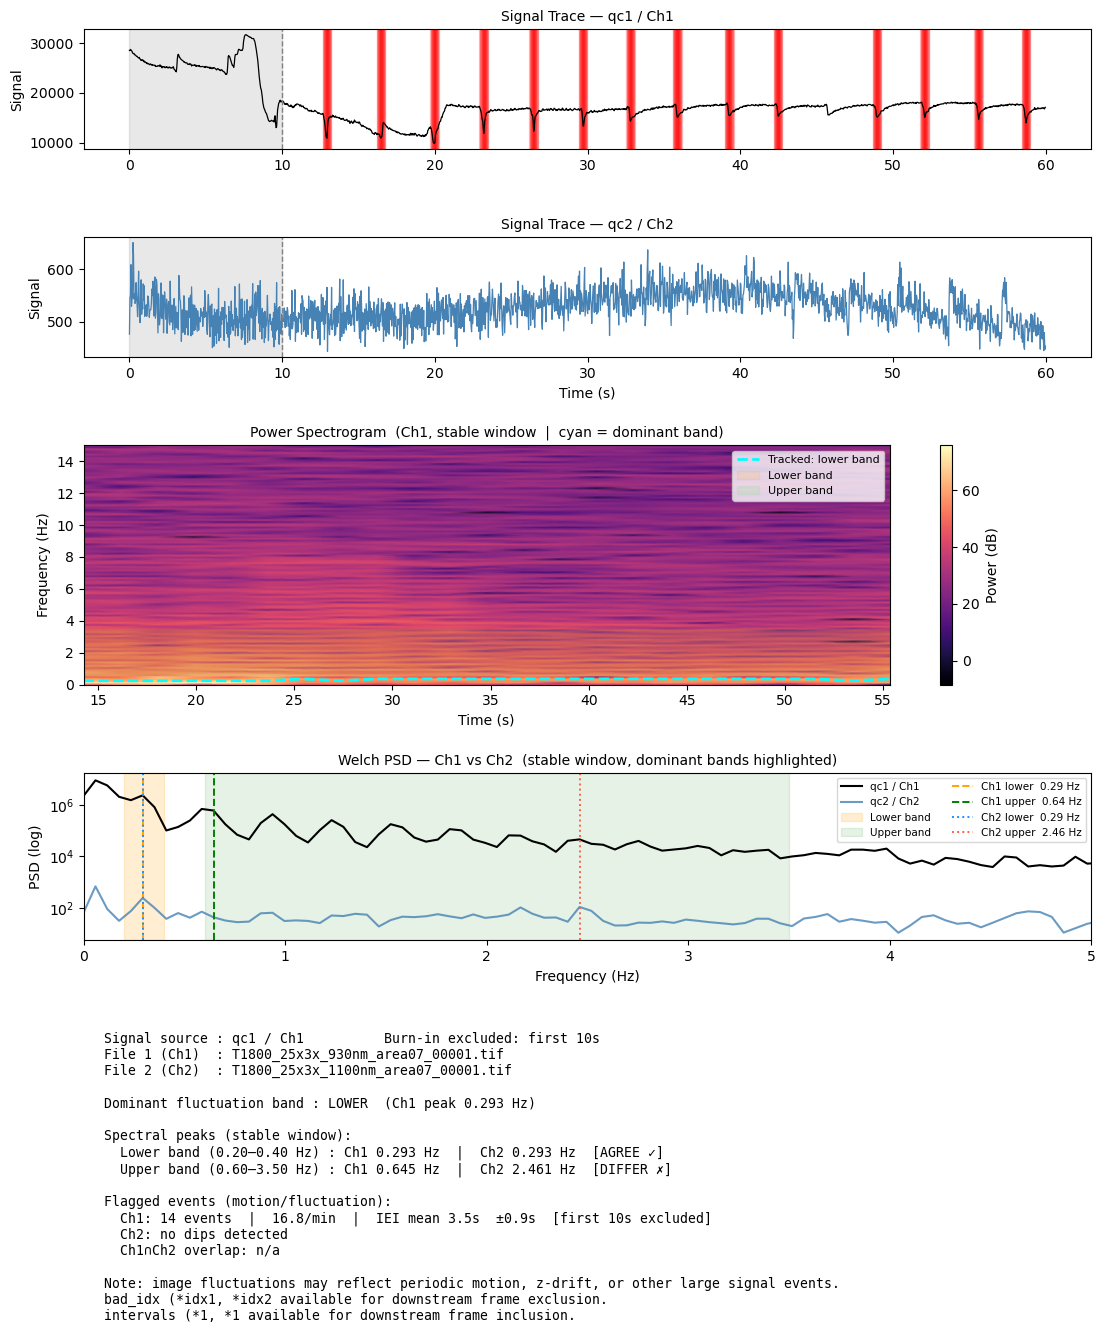

Dominant: lower  |  0.293 Hz
Lower band Ch1/Ch2 agree: True  |  Upper band Ch1/Ch2 agree: False
Ch1 flagged frames: 126  |  Ch2 flagged frames: 0
Cross-channel frame overlap: None


In [323]:
# Redux of
# Claude re-do of 'breathing' code to catch the proper band (SIGH vs actual respiratory rate)

# Take out 'breathe', respiratory language - stick to spectral details
#   Use these steps mainly for tagging out-of-reg slices
#   Index 'jitter' frames using spectral analysis
#   ID a potential 'anesthetic sigh' rate for reference/notes

def plot_clean_fluctuation_qc(x, fs, x2=None, bad_idx=None, intervals=None,
                               nperseg=256, noverlap=200, fmax=15,
                               lower_band_hz=(0.20, 0.40),
                               upper_band_hz=(0.60, 3.50),
                               burn_in_s=10.0,
                               signal_label="qc1 / Ch1",
                               filenames=(tif_filename1, tif_filename2)):

    # ── Burn-in exclusion ──────────────────────────────────────────────────────
    burn_frames = int(burn_in_s * fs)
    x_stable    = np.asarray(x, float)[burn_frames:]
    time_full   = np.arange(len(x)) / fs
    x2_arr      = np.asarray(x2, float) if x2 is not None else None
    x2_stable   = x2_arr[burn_frames:]  if x2_arr is not None else None

    # ── Independent spike detection on Ch2 ────────────────────────────────────
    if x2_stable is not None:
        bad_idx2, Tmask2, intervals2, diag2 = detect_toothy_motion_spikes(
            x2_arr, fs=fs)
        # keep only stable-window events
        bad_idx2_stable    = bad_idx2[bad_idx2 >= burn_frames]
        intervals2_stable  = [(a0, a1) for a0, a1 in intervals2 if a1 >= burn_frames]
    else:
        bad_idx2_stable = intervals2_stable = None

    # Ch1 stable bad_idx
    bad_idx1_stable   = bad_idx[bad_idx >= burn_frames]   if bad_idx   is not None else np.array([])
    intervals1_stable = [(a0,a1) for a0,a1 in intervals if a1 >= burn_frames] if intervals is not None else []

    # ── Welch PSD ─────────────────────────────────────────────────────────────
    def welch_psd(sig):
        return signal.welch(signal.detrend(sig), fs=fs, nperseg=512, noverlap=400)

    f_w, Pxx1 = welch_psd(x_stable)
    Pxx2       = welch_psd(x2_stable)[1] if x2_stable is not None else None

    def band_peak(f, P, lo, hi):
        mask = (f >= lo) & (f <= hi)
        if not mask.any(): return None, 0.0
        idx = np.argmax(P[mask])
        return f[mask][idx], P[mask][idx]

    lower_f1, lower_pwr1 = band_peak(f_w, Pxx1, *lower_band_hz)
    upper_f1, upper_pwr1 = band_peak(f_w, Pxx1, *upper_band_hz)

    if Pxx2 is not None:
        lower_f2, lower_pwr2 = band_peak(f_w, Pxx2, *lower_band_hz)
        upper_f2, upper_pwr2 = band_peak(f_w, Pxx2, *upper_band_hz)
        agree_thr   = 0.05
        lower_agree = lower_f2 is not None and abs(lower_f1 - lower_f2) <= agree_thr
        upper_agree = upper_f2 is not None and abs(upper_f1 - upper_f2) <= agree_thr
    else:
        lower_f2 = upper_f2 = lower_pwr2 = upper_pwr2 = None
        lower_agree = upper_agree = None

    # Dominant band (Ch1 drives spectrogram tracking)
    dominant  = "lower" if lower_pwr1 >= upper_pwr1 else "upper"
    dom_band  = lower_band_hz if dominant == "lower" else upper_band_hz
    dom_f1    = lower_f1      if dominant == "lower" else upper_f1

    # ── Spectrogram ───────────────────────────────────────────────────────────
    x_d = signal.detrend(x_stable)
    f_s, t_s, Sxx = signal.spectrogram(x_d, fs=fs, nperseg=nperseg,
                                        noverlap=noverlap, scaling='density', mode='psd')
    t_s       += burn_in_s
    mask_fmax  = f_s <= fmax
    f_s, Sxx   = f_s[mask_fmax], Sxx[mask_fmax]
    Sxx_db     = 10 * np.log10(Sxx + 1e-12)

    mb             = (f_s >= dom_band[0]) & (f_s <= dom_band[1])
    dom_freq_t     = f_s[mb][np.argmax(Sxx[mb, :], axis=0)]

    # ── Dip stats helper ──────────────────────────────────────────────────────
    def dip_stats(b_idx_stable, ivs_stable, label):
        if b_idx_stable is None or len(b_idx_stable) == 0:
            return f"{label}: no dips detected"
        n        = len(ivs_stable) if ivs_stable else \
                   len(np.where(np.diff(np.concatenate(([-1], b_idx_stable))) > 1)[0])
        dur_s    = len(x_stable) / fs
        rate     = n / (dur_s / 60)
        # inter-event intervals for regularity
        if ivs_stable and len(ivs_stable) > 1:
            centres  = np.array([(a0 + a1) / 2 for a0, a1 in ivs_stable]) / fs
            iei      = np.diff(centres)
            iei_str  = f"IEI mean {iei.mean():.1f}s  ±{iei.std():.1f}s"
        else:
            iei_str  = "IEI n/a"
        return (f"{label}: {n} events  |  {rate:.1f}/min  |  {iei_str}  "
                f"[first {burn_in_s:.0f}s excluded]")

    dip_str1 = dip_stats(bad_idx1_stable,  intervals1_stable,  "Ch1")
    dip_str2 = dip_stats(bad_idx2_stable,  intervals2_stable,  "Ch2") \
               if x2_stable is not None else "Ch2: not provided"

    # ── Cross-channel dip overlap ─────────────────────────────────────────────
    overlap = None  # default
    if x2_stable is not None and len(bad_idx1_stable) and len(bad_idx2_stable):
        overlap = len(np.intersect1d(bad_idx1_stable, bad_idx2_stable))
        overlap_pct = 100 * overlap / max(len(bad_idx1_stable), len(bad_idx2_stable))
        overlap_str = f"Ch1∩Ch2 frame overlap: {overlap} frames  ({overlap_pct:.0f}%)"
    else:
        overlap_str = "Ch1∩Ch2 overlap: n/a"

    # ── Layout ────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 15))
    gs  = fig.add_gridspec(5, 1,
                           height_ratios=[1, 1, 2.0, 1.4, 1.3],
                           hspace=0.55)
    ax_ch1  = fig.add_subplot(gs[0, 0])
    ax_ch2  = fig.add_subplot(gs[1, 0], sharex=ax_ch1)
    ax_spec = fig.add_subplot(gs[2, 0])
    ax_psd  = fig.add_subplot(gs[3, 0])
    ax_txt  = fig.add_subplot(gs[4, 0])
    ax_txt.axis("off")

    # ── Helper: draw signal trace ─────────────────────────────────────────────
    def draw_trace(ax, sig, b_idx_stable, label, color):
        ax.plot(time_full, sig, color=color, linewidth=0.9)
        ax.axvspan(0, burn_in_s, color='gray', alpha=0.18)
        ax.axvline(burn_in_s, color='gray', lw=1.0, ls='--')
        if b_idx_stable is not None and len(b_idx_stable):
            for st in b_idx_stable / fs:
                ax.axvspan(st - 0.15, st + 0.15, color='red', alpha=0.18)
        ax.set_ylabel("Signal")
        ax.set_title(f"Signal Trace — {label}", fontsize=10)

    draw_trace(ax_ch1, x,     bad_idx1_stable, signal_label,                      "black")
    draw_trace(ax_ch2, x2_arr if x2_arr is not None else np.zeros_like(x),
               bad_idx2_stable,
               signal_label.replace("1","2").replace("qc1","qc2"),  "steelblue")
    ax_ch2.set_xlabel("Time (s)")

    # ── Spectrogram ───────────────────────────────────────────────────────────
    im = ax_spec.pcolormesh(t_s, f_s, Sxx_db, shading='gouraud', cmap='magma')
    ax_spec.plot(t_s, dom_freq_t, ls='--', lw=2, color='cyan',
                 label=f'Tracked: {dominant} band')
    ax_spec.axhspan(*lower_band_hz, color='orange', alpha=0.12, label='Lower band')
    ax_spec.axhspan(*upper_band_hz, color='lime',   alpha=0.07, label='Upper band')
    ax_spec.set_ylim(0, fmax)
    ax_spec.set_ylabel("Frequency (Hz)")
    ax_spec.set_xlabel("Time (s)")
    ax_spec.set_title("Power Spectrogram  (Ch1, stable window  |  cyan = dominant band)",
                      fontsize=10)
    ax_spec.legend(fontsize=8, loc='upper right')
    fig.colorbar(im, ax=ax_spec, label="Power (dB)")

    # ── Welch PSD overlay ─────────────────────────────────────────────────────
    ch2_label = signal_label.replace("1","2").replace("qc1","qc2")
    ax_psd.semilogy(f_w, Pxx1, color='black',    lw=1.5, label=signal_label)
    if Pxx2 is not None:
        ax_psd.semilogy(f_w, Pxx2, color='steelblue', lw=1.5, alpha=0.8, label=ch2_label)
    ax_psd.axvspan(*lower_band_hz, color='orange', alpha=0.18, label='Lower band')
    ax_psd.axvspan(*upper_band_hz, color='green',  alpha=0.10, label='Upper band')

    def vline(ax, f, color, ls, label):
        if f: ax.axvline(f, color=color, lw=1.4, ls=ls, label=label)

    vline(ax_psd, lower_f1, 'orange',     '--', f'Ch1 lower  {lower_f1:.2f} Hz')
    vline(ax_psd, upper_f1, 'green',      '--', f'Ch1 upper  {upper_f1:.2f} Hz')
    vline(ax_psd, lower_f2, 'dodgerblue', ':',  f'Ch2 lower  {lower_f2:.2f} Hz' if lower_f2 else '')
    vline(ax_psd, upper_f2, 'tomato',     ':',  f'Ch2 upper  {upper_f2:.2f} Hz' if upper_f2 else '')

    ax_psd.set_xlim(0, 5)
    ax_psd.set_xlabel("Frequency (Hz)")
    ax_psd.set_ylabel("PSD (log)")
    ax_psd.set_title("Welch PSD — Ch1 vs Ch2  (stable window, dominant bands highlighted)",
                     fontsize=10)
    ax_psd.legend(fontsize=7.5, ncol=2)

    # ── Bottom record text ────────────────────────────────────────────────────
    fn1 = filenames[0] if filenames and len(filenames) > 0 else "n/a"
    fn2 = filenames[1] if filenames and len(filenames) > 1 else "n/a"

    def agree_str(a):
        if a is None: return "n/a"
        return "AGREE ✓" if a else "DIFFER ✗"

    record = (
        f"Signal source : {signal_label}          Burn-in excluded: first {burn_in_s:.0f}s\n"
        f"File 1 (Ch1)  : {fn1}\n"
        f"File 2 (Ch2)  : {fn2}\n\n"
        f"Dominant fluctuation band : {dominant.upper()}  "
        f"(Ch1 peak {dom_f1:.3f} Hz)\n\n"
        f"Spectral peaks (stable window):\n"
        f"  Lower band ({lower_band_hz[0]:.2f}–{lower_band_hz[1]:.2f} Hz) : "
        f"Ch1 {lower_f1:.3f} Hz  |  "
        + (f"Ch2 {lower_f2:.3f} Hz  [{agree_str(lower_agree)}]" if lower_f2 else "Ch2 n/a") + "\n"
        f"  Upper band ({upper_band_hz[0]:.2f}–{upper_band_hz[1]:.2f} Hz) : "
        f"Ch1 {upper_f1:.3f} Hz  |  "
        + (f"Ch2 {upper_f2:.3f} Hz  [{agree_str(upper_agree)}]" if upper_f2 else "Ch2 n/a") + "\n\n"
        f"Flagged events (motion/fluctuation):\n"
        f"  {dip_str1}\n"
        f"  {dip_str2}\n"
        f"  {overlap_str}\n\n"
        f"Note: image fluctuations may reflect periodic motion, z-drift, "
        f"or other large signal events.\n"
        f"bad_idx (*idx1, *idx2 available for downstream frame exclusion.\n"
        f"intervals (*1, *1 available for downstream frame inclusion."
    )
    ax_txt.text(0.02, 0.98, record, fontsize=9.5, va='top', family='monospace')

    plt.show()

    return {
        "dominant":      dominant,
        "dom_freq_hz":   dom_f1,
        "lower_f_ch1":   lower_f1,  "lower_f_ch2":   lower_f2,
        "upper_f_ch1":   upper_f1,  "upper_f_ch2":   upper_f2,
        "lower_agree":   lower_agree, "upper_agree":   upper_agree,
        "bad_idx_ch1":   bad_idx1_stable,
        "bad_idx_ch2":   bad_idx2_stable,
        "intervals_ch1": intervals1_stable,
        "intervals_ch2": intervals2_stable,
        "overlap_frames": overlap if x2_stable is not None else None,
    }


# ── Run ───────────────────────────────────────────────────────────────────────
bad_idx1, Tmask1, intervals1, diag1 = detect_toothy_motion_spikes(qc1['top_mean'], fs=30)
bad_idx2, Tmask2, intervals2, diag2 = detect_toothy_motion_spikes(qc2['top_mean'], fs=30)

out = plot_clean_fluctuation_qc(
    x=qc1['top_mean'],
    x2=qc2['top_mean'],
    fs=30,
    bad_idx=bad_idx1,
    intervals=intervals1,
    nperseg=256,
    noverlap=200,
    fmax=15,
    lower_band_hz=(0.20, 0.40),
    upper_band_hz=(0.60, 3.50),
    burn_in_s=10.0,
    signal_label="qc1 / Ch1",
    filenames=(tif_filename1, tif_filename2)
)

print(f"Dominant: {out['dominant']}  |  {out['dom_freq_hz']:.3f} Hz")
print(f"Lower band Ch1/Ch2 agree: {out['lower_agree']}  |  "
      f"Upper band Ch1/Ch2 agree: {out['upper_agree']}")
print(f"Ch1 flagged frames: {len(out['bad_idx_ch1'])}  |  "
      f"Ch2 flagged frames: {len(out['bad_idx_ch2'])}")
print(f"Cross-channel frame overlap: {out['overlap_frames']}")

In [335]:
# FUTURE: - Save data CSV, NPZ and/or PKL
#         - Read in metadata from accompanying NPZ for PKL file(s)
# # tif_filename
# plt.plot(qc2['top_mean'])

In [325]:
# # Arrray input - Shading the signal plot

# def shade_intervals(ax, intervals, fs, alpha=0.18):
#     for a0, a1 in intervals:
#         ax.axvspan(a0/fs, (a1+1)/fs, color="red", alpha=alpha, linewidth=0)

# # Example:
# # bad_idx, Tmask, intervals, diag = detect_toothy_motion_spikes(x, fs=30)
# # fig, ax = plt.subplots(figsize=(12,3))
# # t = np.arange(len(x))/30
# # ax.plot(t, x, color="black", lw=1)
# # shade_intervals(ax, intervals, fs=30)
# # plt.show()

# x=qc1['top_mean']
# fs=30
# bad_idx, Tmask, intervals, diag = detect_toothy_motion_spikes(x, fs=fs)
# fig, ax = plt.subplots(figsize=(12,3))
# t = np.arange(len(x))/fs
# ax.plot(t, x, color="black", lw=1)
# shade_intervals(ax, intervals, fs=fs)
# plt.show()


In [326]:
# BELOW SECTIONS - STRIPING DETECTOR (eg due to misaligned linescans during bidirectional scans)

# import numpy as np
# import matplotlib.pyplot as plt
from numpy.fft import fft, fftfreq

def stripe_qc(data, axis='rows', fs_spatial=None, plot=True):
    """
    data: 2D (Y,X) or 3D (T,Y,X)
    axis: 'rows' (horizontal banding) or 'cols'
    fs_spatial: pixels per micron (optional, for physical freq)
    """

    # --- Collapse time if needed ---
    if data.ndim == 3:
        img = data.mean(axis=0)
    else:
        img = data.copy()

    img = img.astype(float)

    # --- Choose direction ---
    if axis == 'rows':
        line_profile = img.mean(axis=1)
    else:
        line_profile = img.mean(axis=0)

    # Remove DC offset
    line_profile = line_profile - np.mean(line_profile)

    # --- Stripe score ---
    stripe_score = np.std(line_profile) / np.std(img)

    # --- Odd-even test ---
    even = line_profile[::2]
    odd  = line_profile[1::2]
    odd_even_offset = np.abs(np.mean(even) - np.mean(odd))

    # --- FFT analysis ---
    N = len(line_profile)
    F = np.abs(fft(line_profile))
    freqs = fftfreq(N)

    # Ignore DC
    F[0] = 0

    peak_idx = np.argmax(F[:N//2])
    peak_freq = freqs[peak_idx]
    peak_power = F[peak_idx] / np.sum(F)

    if plot:
        fig, axs = plt.subplots(2,1, figsize=(6,6))

        axs[0].plot(line_profile)
        axs[0].set_title(f"Line Mean Profile | Stripe score = {stripe_score:.3f}")

        axs[1].plot(freqs[:N//2], F[:N//2])
        axs[1].set_title(f"FFT | Peak freq = {peak_freq:.4f} | Power frac = {peak_power:.3f}")
        axs[1].set_xlabel("Spatial frequency (cycles/pixel)")

        plt.tight_layout()
        plt.show()

    return {
        "stripe_score": stripe_score,
        "odd_even_offset": odd_even_offset,
        "peak_freq_cycles_per_pixel": peak_freq,
        "peak_power_fraction": peak_power
    }

def compare_channels(stack_ch1, stack_ch2):

    m1 = stripe_qc(stack_ch1, plot=False)
    m2 = stripe_qc(stack_ch2, plot=False)

    print("Channel 1:")
    for k,v in m1.items():
        print(f"  {k}: {v:.4f}")

    print("\nChannel 2:")
    for k,v in m2.items():
        print(f"  {k}: {v:.4f}")

    print("\nFrequency difference:",
          abs(m1["peak_freq_cycles_per_pixel"] -
              m2["peak_freq_cycles_per_pixel"]))

# Go back to:
data_tyx_ch1 = tif_binned[:, 0, :, :]  # shape: (33, 512, 512)
data_tyx_ch2 = tif_binned[:, 1, :, :]  # shape: (33, 512, 512)

print(f"Channel 1   shape: {data_tyx_ch1.shape}")
print(f"Channel 2   shape: {data_tyx_ch2.shape}")

Channel 1   shape: (1800, 512, 512)
Channel 2   shape: (1800, 512, 512)


In [327]:
compare_channels(data_tyx_ch1, data_tyx_ch2)

Channel 1:
  stripe_score: 0.5430
  odd_even_offset: 21.0447
  peak_freq_cycles_per_pixel: 0.0039
  peak_power_fraction: 0.0419

Channel 2:
  stripe_score: 0.2088
  odd_even_offset: 0.8760
  peak_freq_cycles_per_pixel: 0.0156
  peak_power_fraction: 0.0476

Frequency difference: 0.01171875


In [328]:
# import numpy as np
# import matplotlib.pyplot as plt

def odd_even_artifact_map(img):
    img = img.astype(float)
    row_mean = img.mean(axis=1)

    even_med = np.median(row_mean[::2])
    odd_med  = np.median(row_mean[1::2])

    # alternating per-row offset relative to midline
    alt = np.zeros_like(row_mean)
    alt[::2] = even_med
    alt[1::2] = odd_med
    alt = alt - np.mean(alt)

    artifact = alt[:, None] * np.ones((1, img.shape[1]))
    return artifact

def artifact_mask_and_hist(img, z=2.5, bins=200):
    img = img.astype(float)
    artifact = odd_even_artifact_map(img)

    # robust scale threshold
    mad = np.median(np.abs(artifact - np.median(artifact))) + 1e-12
    score = np.abs(artifact) / (1.4826 * mad)
    mask = score >= z

    # intensity distributions
    band_vals = img[mask]
    non_vals  = img[~mask]

    plt.figure(figsize=(10,3))
    plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("Raw"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title(f"Band mask (z>={z})"); plt.axis("off")
    plt.subplot(1,3,3)
    plt.hist(non_vals.ravel(), bins=bins, alpha=0.6, label="non-band")
    plt.hist(band_vals.ravel(), bins=bins, alpha=0.6, label="band")
    plt.title("Raw intensity distributions"); plt.legend()
    plt.tight_layout(); plt.show()

    return mask, artifact

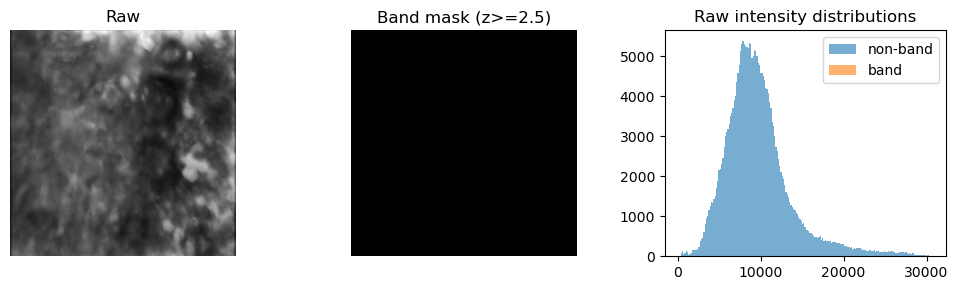

In [329]:
img1 = data_tyx_ch1.mean(axis=0)
mask1, artifact1 = artifact_mask_and_hist(img1, z=2.5)

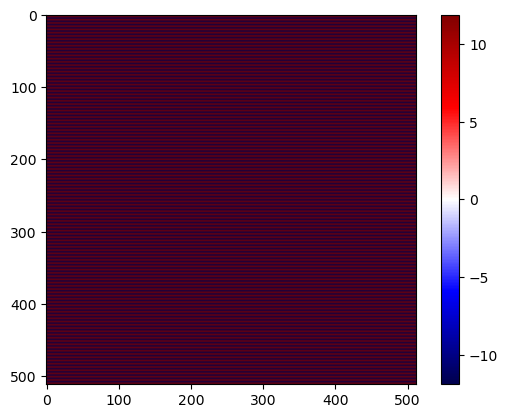

In [330]:
plt.imshow(artifact1, cmap="seismic")
plt.colorbar()

In [331]:
# import numpy as np
# import matplotlib.pyplot as plt

def robust_artifact_qc(data, *, axis='rows', use_mean_over_time=True,
                       smooth_win=41, make_plots=True, title=""):
    """
    data: 2D (Y,X) or 3D (T,Y,X)
    axis: 'rows' or 'cols' (banding direction you suspect)
    smooth_win: for baseline removal on row/col mean profile
    Returns dict of artifact metrics + artifact maps.
    """
    # --- choose frame ---
    if data.ndim == 3 and use_mean_over_time:
        img = data.mean(axis=0).astype(float)
    else:
        img = data.astype(float)

    Y, X = img.shape

    # --- line mean profile ---
    if axis == 'rows':
        prof = img.mean(axis=1)  # length Y
    else:
        prof = img.mean(axis=0)  # length X

    # --- baseline removal (slow drift across FOV) ---
    def moving_avg(x, win):
        win = int(win)
        if win < 3:
            return x.copy()
        if win % 2 == 0:
            win += 1
        pad = win // 2
        xpad = np.pad(x, (pad, pad), mode="reflect")
        k = np.ones(win) / win
        return np.convolve(xpad, k, mode="valid")

    base = moving_avg(prof, smooth_win)
    resid = prof - base
    resid = resid - np.mean(resid)

    # --- odd-even component strength (very diagnostic for ScanImage timing) ---
    even = resid[::2]
    odd  = resid[1::2]
    odd_even = np.mean(even) - np.mean(odd)          # signed
    odd_even_abs = np.abs(odd_even)                  # magnitude

    # Build explicit odd-even artifact map
    alt = np.zeros_like(resid)
    alt[::2] = np.mean(even)
    alt[1::2] = np.mean(odd)
    alt = alt - np.mean(alt)

    if axis == 'rows':
        artifact_oe = alt[:, None] * np.ones((1, X))
    else:
        artifact_oe = np.ones((Y, 1)) * alt[None, :]

    # --- spectral banding: how much power is in non-DC periodic structure? ---
    # 1D FFT of residual line-profile
    F = np.fft.rfft(resid)
    P = (np.abs(F) ** 2)
    P[0] = 0  # ignore DC

    # total periodic power fraction
    periodic_power_frac = P.sum() / (np.sum(resid**2) + 1e-12)

    # dominant frequency (cycles per sample)
    freqs = np.fft.rfftfreq(len(resid), d=1.0)
    peak_idx = np.argmax(P[1:]) + 1
    peak_freq = freqs[peak_idx]
    peak_power_frac = P[peak_idx] / (P.sum() + 1e-12)

    # Convert peak_freq to "pixels per cycle"
    peak_period_px = (1.0 / peak_freq) if peak_freq > 0 else np.inf

    # --- 2D FFT energy concentration (checkerboard/texture-like periodicity) ---
    # This is a global metric: how "spiky" the 2D spectrum is away from DC.
    F2 = np.fft.fftshift(np.fft.fft2(img - np.mean(img)))
    P2 = np.abs(F2) ** 2
    cy, cx = Y // 2, X // 2
    P2[cy-2:cy+3, cx-2:cx+3] = 0  # remove central DC-ish blob

    # "peakiness": max / median of spectrum (robust)
    spec_peakiness = (np.max(P2) / (np.median(P2) + 1e-12))

    out = dict(
        odd_even_signed=odd_even,
        odd_even_abs=odd_even_abs,
        periodic_power_frac=periodic_power_frac,
        peak_freq_cycles_per_pixel=peak_freq,   # along the prof axis
        peak_period_pixels=peak_period_px,
        peak_power_frac=peak_power_frac,
        spec_peakiness_2d=spec_peakiness,
        img_mean=float(np.mean(img)),
        img_std=float(np.std(img)),
        resid=resid,
        freqs=freqs,
        P=P,
        artifact_oe=artifact_oe,
        img=img
    )

    if make_plots:
        fig = plt.figure(figsize=(12, 3.6))

        ax1 = plt.subplot(1, 3, 1)
        ax1.imshow(img, cmap="gray")
        ax1.set_title("Mean image" if (data.ndim==3 and use_mean_over_time) else "Image")
        ax1.axis("off")

        ax2 = plt.subplot(1, 3, 2)
        ax2.plot(resid, lw=1)
        ax2.set_title(f"{axis} residual | odd-even={odd_even_abs:.2f}")
        ax2.set_xlabel("Line index")
        ax2.set_ylabel("Residual (a.u.)")

        ax3 = plt.subplot(1, 3, 3)
        ax3.plot(freqs[1:], P[1:], lw=1)
        ax3.set_title(f"1D FFT | peak period≈{peak_period_px:.1f}px | peak frac={peak_power_frac:.3f}")
        ax3.set_xlabel("cycles/pixel")
        ax3.set_ylabel("Power")

        plt.suptitle(title, y=1.02)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(6, 4))
        plt.imshow(out["artifact_oe"], cmap="seismic")
        plt.colorbar()
        plt.title("Odd-even artifact map (signed)")
        plt.tight_layout()
        plt.show()

    return out

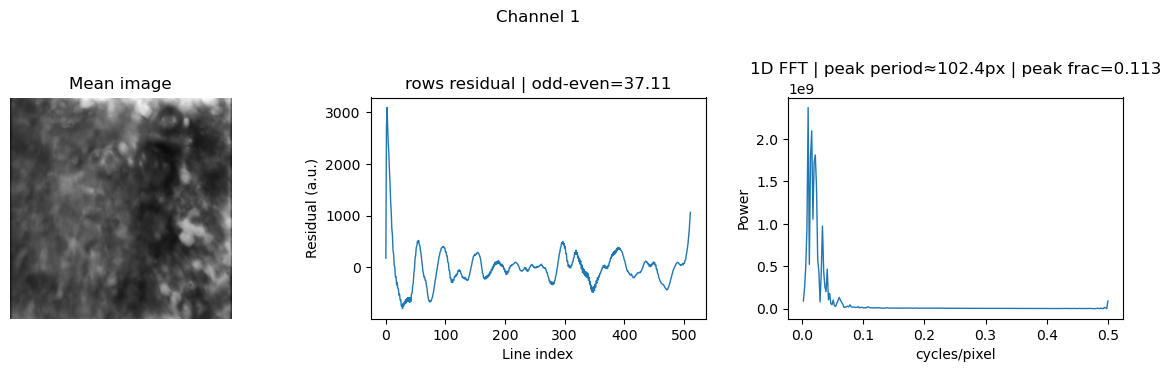

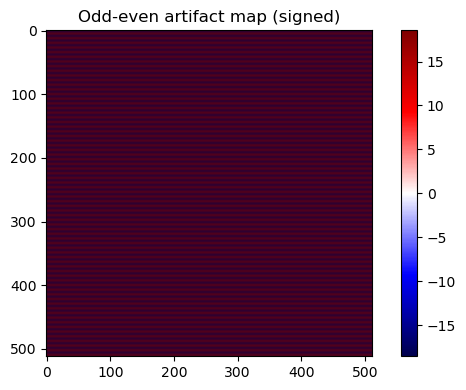

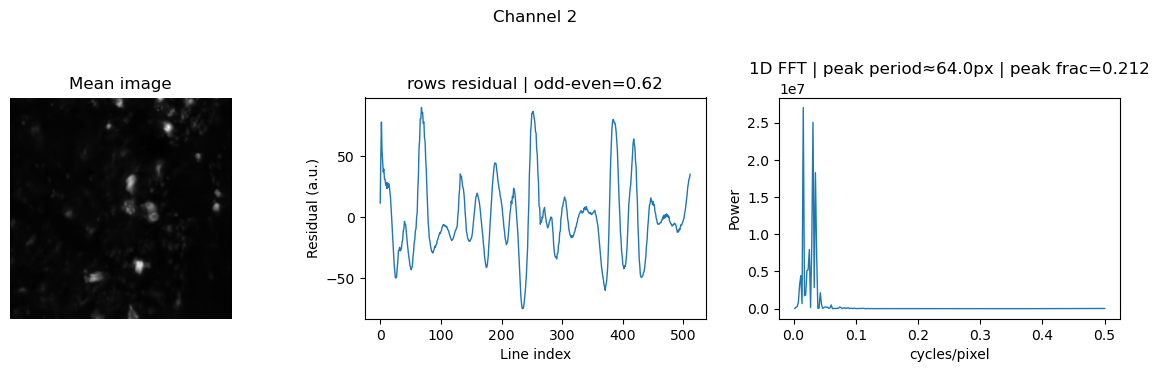

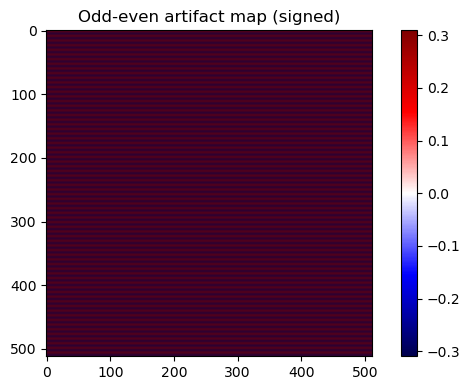

odd_even_abs Ch1: 37.109797618318055 Ch2: 0.618771060747182
periodic_power_frac Ch1: 256.55315769026197 Ch2: 256.02524648216036
peak_period_pixels Ch1: 102.4 Ch2: 64.0
peak_power_frac Ch1: 0.11332631873834649 Ch2: 0.21242090720536266
spec_peakiness_2d Ch1: 13873373.5986113 Ch2: 1100608.984936937


In [332]:
qc1_input = robust_artifact_qc(data_tyx_ch1, axis='rows', title="Channel 1")
qc2_input = robust_artifact_qc(data_tyx_ch2, axis='rows', title="Channel 2")

for k in ["odd_even_abs","periodic_power_frac","peak_period_pixels","peak_power_frac","spec_peakiness_2d"]:
    print(k, "Ch1:", qc1_input[k], "Ch2:", qc2_input[k])

In [333]:
# import numpy as np
# import matplotlib.pyplot as plt
"""
What this produces

For Ch1 (T,Y,X) and Ch2 (T,Y,X):

segments Ch1 into stable windows (plateaus)

for each window:

select ~12 frames (evenly spaced)

compute Tavg_ch1_candidate

compute registration score to Tavg_ch2_ref (edge-based NCC + optional phase-corr shift/peak)

returns the top 3 candidates with:

frame ranges

the selected frame indices

scores (stability + registration + estimated shift)
"""

# Plateau detection + top-3 Tavg candidates for registration
# ---------- small helpers ----------
def robust_z(x):
    x = np.asarray(x, float)
    med = np.median(x)
    mad = np.median(np.abs(x - med)) + 1e-12
    return (x - med) / (1.4826 * mad)

def ncc(a, b):
    a = a.astype(np.float32); b = b.astype(np.float32)
    a = a - a.mean(); b = b - b.mean()
    denom = (np.sqrt((a*a).sum()) * np.sqrt((b*b).sum()) + 1e-12)
    return float((a*b).sum() / denom)

def edge_map(img):
    """Simple high-pass via 3x3 mean subtraction (dependency-free)."""
    img = img.astype(np.float32)
    k = 3
    pad = k//2
    p = np.pad(img, ((pad,pad),(pad,pad)), mode="reflect")
    blur = (p[:-2,:-2] + p[:-2,1:-1] + p[:-2,2:] +
            p[1:-1,:-2] + p[1:-1,1:-1] + p[1:-1,2:] +
            p[2:,:-2] + p[2:,1:-1] + p[2:,2:]) / 9.0
    return img - blur

def phase_corr_shift(a, b):
    """
    Phase correlation to estimate translation. Returns (dy, dx, peak_value).
    peak_value is a registration confidence proxy.
    """
    a = a.astype(np.float32) - np.mean(a)
    b = b.astype(np.float32) - np.mean(b)
    Fa = np.fft.fft2(a)
    Fb = np.fft.fft2(b)
    R = Fa * np.conj(Fb)
    R /= (np.abs(R) + 1e-12)
    r = np.fft.ifft2(R)
    r = np.abs(r)
    peak = r.max()
    iy, ix = np.unravel_index(np.argmax(r), r.shape)

    # wrap-around to signed shift
    dy = iy if iy < a.shape[0]//2 else iy - a.shape[0]
    dx = ix if ix < a.shape[1]//2 else ix - a.shape[1]
    return int(dy), int(dx), float(peak)

# ---------- per-frame similarity (for "Z-hunting" detection) ----------
def frame_to_prev_similarity(stack_tyx, use_edges=True):
    """
    Returns sim[t] = NCC(frame[t], frame[t-1]) (or edge-NCC).
    High => stable plane; low dips => Z moves / jumps.
    """
    T = stack_tyx.shape[0]
    sim = np.zeros(T, float)
    prev = None
    for t in range(T):
        img = stack_tyx[t]
        if use_edges:
            img = edge_map(img)
        if prev is None:
            sim[t] = 0.0
        else:
            sim[t] = ncc(img, prev)
        prev = img
    return sim

def find_stable_windows(sim, *, burn_in=0, min_len=30, z_thr=-1.0):
    """
    Identify contiguous windows where similarity is high.
    z_thr is a robust z threshold on similarity; default -1 keeps most, then we prune by length.
    """
    sim = np.asarray(sim, float)
    z = robust_z(sim)
    good = (np.arange(len(sim)) >= burn_in) & (z >= z_thr)

    windows = []
    i = 0
    while i < len(sim):
        if not good[i]:
            i += 1
            continue
        j = i
        while j < len(sim) and good[j]:
            j += 1
        if (j - i) >= min_len:
            windows.append((i, j))  # [i, j)
        i = j
    return windows, good, z

def select_frames_in_window(start, stop, n_select=12):
    idx = np.arange(start, stop)
    if len(idx) <= n_select:
        return idx
    pick = np.linspace(0, len(idx)-1, n_select).round().astype(int)
    return idx[pick]

def laplacian_var(img):
    """Variance of discrete Laplacian (sharpness proxy)."""
    img = img.astype(np.float32)
    lap = (-4*img +
           np.roll(img, 1, 0) + np.roll(img, -1, 0) +
           np.roll(img, 1, 1) + np.roll(img, -1, 1))
    return float(lap.var())

def structure_energy(img):
    """Edge/texture energy proxy (more robust than Laplacian var to intensity changes)."""
    img = img.astype(np.float32)
    # simple gradients
    gx = img - np.roll(img, 1, axis=1)
    gy = img - np.roll(img, 1, axis=0)
    return float(np.mean(gx*gx + gy*gy))

def bright_frac(img, q=99.9):
    thr = np.percentile(img, q)
    return float((img >= thr).mean())

# ---------- main: top 3 Ch1 candidates vs Ch2 reference ----------
def top_ch1_tavg_candidates_for_ch2(
    ch1_tyx, ch2_tyx,
    *, burn_in=0, min_len=40, sim_z_thr=-0.2,
    n_select=12, max_abs_shift=40,
    score_weights=(0.4, 0.6),  # (stability, registration)
    use_phasecorr=True,
    debug_plots=True,
    top_k=5
):
    """
    Returns list of dicts (top 3 by combined score).
    Each dict contains window range, selected frames, scores, shift estimate, and Tavg image.
    """

    # Ch2 reference: you can swap this for your own "best frames" selection if desired
    ref2 = ch2_tyx.mean(axis=0).astype(np.float32)
    ref2e = edge_map(ref2)

    # 1) detect stable windows in Ch1 using frame-to-prev similarity (edge-NCC)
    sim = frame_to_prev_similarity(ch1_tyx, use_edges=True)
    windows, good, zsim = find_stable_windows(sim, burn_in=burn_in, min_len=min_len, z_thr=sim_z_thr)

    candidates = []
    for (s, e) in windows:
        # sel = select_frames_in_window(s, e, n_select=n_select)
        # tavg1 = ch1_tyx[sel].mean(axis=0).astype(np.float32)
        # candidate frames in the window
        idx = np.arange(s, e)
        
        # focus metric per frame (sharpness proxy; still works fine for “Z hunting”)
        # focus_scores = np.array([laplacian_var(ch1_tyx[t]) for t in idx], dtype=float)
        focus_scores = np.array([structure_energy(ch1_tyx[t]) for t in idx], dtype=float)
        
        # take top N frames by focus
        top_local = np.argsort(focus_scores)[-n_select:]          # indices within the window
        sel = idx[np.sort(top_local)]                             # actual frame indices (sorted for readability)
        
        tavg1 = ch1_tyx[sel].mean(axis=0).astype(np.float32)

        # stab    = plateau stability metric
        # reg_ncc = edge-NCC registration score

        # stability score: median similarity inside the window (exclude first point)
        stab = float(np.median(sim[s+1:e])) if (e - s) > 2 else float(sim[s])

        # registration score: edge NCC + optional phase-corr peak, penalize huge shifts
        tavg1e = edge_map(tavg1)
        reg_ncc = ncc(tavg1e, ref2e)

        dy = dx = 0
        pc_peak = 0.0
        # shift_pen = 1.0
        # if use_phasecorr:
        #     dy, dx, pc_peak = phase_corr_shift(tavg1e, ref2e)
        #     if (abs(dy) > max_abs_shift) or (abs(dx) > max_abs_shift):
        #         shift_pen = 0.0  # effectively disqualify
        # reg = reg_ncc
        # if use_phasecorr:
        #     # blend NCC and phasecorr peak (peak is usually small-ish; we z-normalize lightly)
        #     reg = 0.7 * reg_ncc + 0.3 * (pc_peak / (np.median([pc_peak, 1e-6]) + 1e-6))

        # w_stab, w_reg = score_weights
        # combined = shift_pen * (w_stab * stab + w_reg * reg)
        # new scoring (no shift penalty)
        # registration
        dy, dx, pc_peak = phase_corr_shift(tavg1e, ref2e)
        # combined = 0.6 * reg_ncc + 0.4 * stab
        # combined = 0.6*reg_ncc + 0.4*stab - 0.2*bright_frac(tavg1)
        shift_penalty = abs(dx) / max_abs_shift
        shift_penalty = min(shift_penalty, 1.0)
        combined = (
            0.6 * reg_ncc +
            0.4 * stab -
            0.2 * bright_frac(tavg1) -
            0.3 * shift_penalty
        )

        # inside window loop, after computing dy/dx/reg_ncc/stab/tavg1
        bright = bright_frac(tavg1)
        
        candidates.append(dict(
            start=s, stop=e,
            selected_frames=sel,
            stability=stab,
            reg_ncc_edge=reg_ncc,
            dy=dy, dx=dx,
            bright=bright,
            tavg_ch1=tavg1
        ))
        
    # AFTER the loop, before sorting:
    #DEBUG STEP
    print("Have bright in all candidates?", all(("bright" in c) for c in candidates))
    dx0 = np.median([c["dx"] for c in candidates]) if candidates else 0.0
    for c in candidates:
        shift_pen = abs(c["dx"] - dx0) / 40.0
        c["combined_score"] = 0.6*c["reg_ncc_edge"] + 0.4*c["stability"] - 0.2*c["bright"] - 0.6*shift_pen
    
    candidates.sort(key=lambda d: d["combined_score"], reverse=True)
    topk = candidates[:top_k]
    # # sort + take top 3
    # candidates.sort(key=lambda d: d["combined_score"], reverse=True)
    # # top3 = candidates[:3]
    # topk = candidates[:top_k]

    if debug_plots:
        # plot similarity trace + windows + chosen candidates
        plt.figure(figsize=(12,3))
        plt.plot(sim, lw=1)
        for (s,e) in windows:
            plt.axvspan(s, e, alpha=0.08)
        for k, c in enumerate(topk):
            plt.axvspan(c["start"], c["stop"], alpha=0.18)
            plt.scatter(c["selected_frames"], sim[c["selected_frames"]], s=18, label=f"Top{k+1}")
        plt.title("Ch1 frame-to-prev similarity (edge-NCC) with stable windows")
        plt.xlabel("Frame"); plt.ylabel("Similarity")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # show the top3 Tavg images + reference Ch2 for quick visual sanity
        # fig, axs = plt.subplots(1, 4, figsize=(14,3.5))
        # axs[0].imshow(ref2, cmap="gray"); axs[0].set_title("Ch2 reference (mean)"); axs[0].axis("off")
        # for i, c in enumerate(top3):
        #     axs[i+1].imshow(c["tavg_ch1"], cmap="gray")
        #     axs[i+1].set_title(f"Ch1 cand {i+1}\nframes {c['start']}:{c['stop']}\nNCC={c['reg_ncc_edge']:.3f}, shift=({c['dy']},{c['dx']})")
        #     axs[i+1].axis("off")
        # plt.tight_layout()
        # plt.show()
        # fig, axs = plt.subplots(4,4, figsize=(14,10))
        ncols = 1 + len(topk)  # Ch2 ref + candidates
        fig, axs = plt.subplots(4, ncols, figsize=(3.6*ncols, 10))

        # row 1 already used by similarity plot
        
        # row 2
        axs[1,0].imshow(ref2, cmap='gray')
        axs[1,0].set_title("Ch2 reference")
        
        for i,c in enumerate(topk):
            axs[1,i+1].imshow(c['tavg_ch1'], cmap='gray')
            axs[1,i+1].set_title(f"Ch1 cand {i+1}")
        
        # row 3 overlays
        for i,c in enumerate(topk):
            overlay = overlay_grn_red(c['tavg_ch1'], ref2)
            axs[2,i+1].imshow(overlay)
            axs[2,i+1].set_title("overlay")
        
        axs[2,0].axis("off")
        
        # row 4 best candidate
        best = topk[0]
        
        axs[3,1].imshow(best['tavg_ch1'], cmap='gray')
        axs[3,1].set_title("Best Ch1")
        
        axs[3,2].imshow(ref2, cmap='gray')
        axs[3,2].set_title("Ch2")
        
        axs[3,3].imshow(overlay_grn_red(best['tavg_ch1'], ref2))
        axs[3,3].set_title("Best overlay")
        
        axs[3,0].axis("off")
        
        plt.tight_layout()
        plt.show()

    return topk # return top3

def overlay_grn_red(ch1, ch2):
    ch1 = ch1.astype(float)
    ch2 = ch2.astype(float)

    ch1 = (ch1 - ch1.min())/(ch1.max()-ch1.min()+1e-9)
    ch2 = (ch2 - ch2.min())/(ch2.max()-ch2.min()+1e-9)

    rgb = np.zeros((*ch1.shape,3))
    rgb[:,:,1] = ch1   # green
    rgb[:,:,0] = ch2   # red

    return rgb

Have bright in all candidates? True


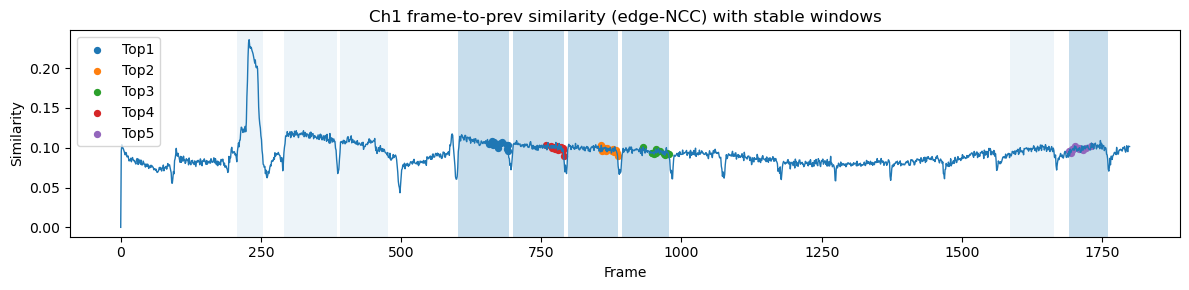

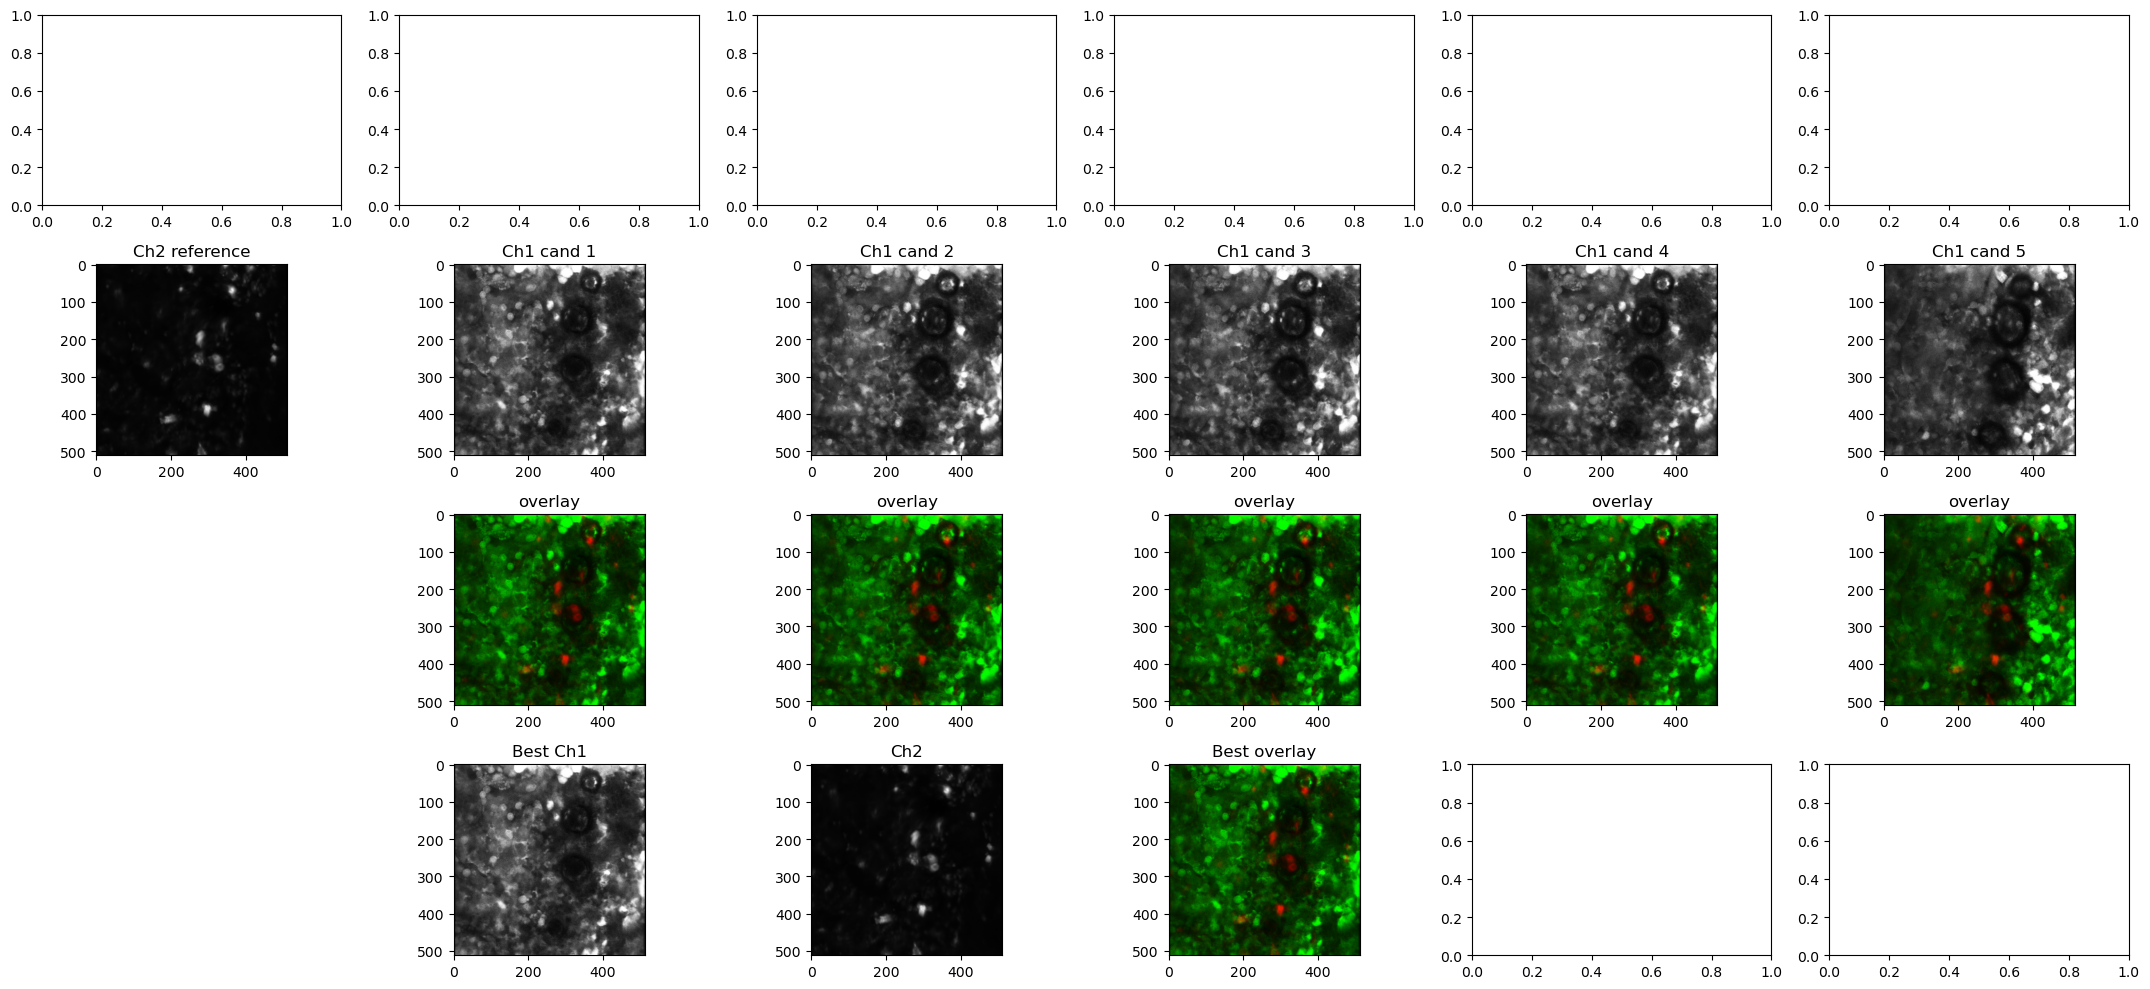

Top 1: frames 602:692 | stab=0.107 | NCCedge=0.218 | shift=(0,-86) | score=0.173
Top 2: frames 797:887 | stab=0.099 | NCCedge=0.206 | shift=(0,-86) | score=0.163
Top 3: frames 894:978 | stab=0.096 | NCCedge=0.202 | shift=(0,-86) | score=0.159
Top 4: frames 699:791 | stab=0.102 | NCCedge=0.216 | shift=(0,-88) | score=0.139
Top 5: frames 1691:1760 | stab=0.099 | NCCedge=0.182 | shift=(0,-47) | score=-0.437


In [334]:
"""
Practical recommendations for your setting

If the operator is “scrubbing” quickly, set min_len lower (20–30).

If you want only very stable plateaus, raise sim_z_thr (e.g., 0.0).

If Ch1 and Ch2 are different FOVs, the shift will blow up;
the max_abs_shift penalty will keep you from picking nonsense candidates.
"""

top5 = top_ch1_tavg_candidates_for_ch2(
    data_tyx_ch1, data_tyx_ch2,
    burn_in=0,          # set to 50–200 if you always have “settling” at start
    min_len=40,         # plateau must last at least this many frames
    sim_z_thr=-0.2,     # loosen/tighten depending on how jumpy the operator is
    n_select=12,
    max_abs_shift=40,
    use_phasecorr=True,
    debug_plots=True,
    top_k=5
)

for i, c in enumerate(top5, 1):
    print(f"Top {i}: frames {c['start']}:{c['stop']} | "
          f"stab={c['stability']:.3f} | NCCedge={c['reg_ncc_edge']:.3f} | "
          f"shift=({c['dy']},{c['dx']}) | score={c['combined_score']:.3f}")